In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

## Configuración

In [2]:
api_key = input("Introduce tu clave de OpenAI: ")
os.environ["OPENAI_API_KEY"] = api_key


# 1️⃣ **Cargar datos y separar train-test**

In [3]:
# Cargamos el dataset
df = pd.read_csv('../data/raw/BankChurners.csv')

# Mostramos las primeras 5 filas para ver la estructura
df.head()


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


En esta primera fase nos enfocaremos en preparar el dataset para los modelos. La idea es dividir el conjunto de datos en subconjuntos para entrenar y evaluar el modelo de manera justa.

In [4]:
from sklearn.model_selection import train_test_split

# Creamos una función para dividir el dataset en entrenamiento (80%) y prueba (20%)
def split_train_test(df):
  train_X, test_X = train_test_split(df, test_size=0.2, random_state=42)
  return train_X, test_X

In [5]:
train_X, test_X = split_train_test(df)

In [6]:
# Mostramos los primeros registros del conjunto de entrenamiento
train_X.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
9066,713071383,Existing Customer,54,F,1,Unknown,Single,Unknown,Blue,36,...,3,3,3723.0,1728,1995.0,0.595,8554,99,0.678,0.464
5814,714246333,Attrited Customer,58,F,4,High School,Married,Unknown,Blue,48,...,4,3,5396.0,1803,3593.0,0.493,2107,39,0.393,0.334
792,718206783,Existing Customer,45,F,4,Unknown,Single,Less than $40K,Gold,36,...,1,3,15987.0,1648,14339.0,0.732,1436,36,1.250,0.103
1791,721096983,Existing Customer,34,F,2,Graduate,Single,Less than $40K,Blue,36,...,3,4,3625.0,2517,1108.0,1.158,2616,46,1.300,0.694
5011,720028683,Existing Customer,49,F,2,High School,Married,$40K - $60K,Blue,39,...,3,4,2720.0,1926,794.0,0.602,3806,61,0.794,0.708


In [7]:
# Mostramos los primeros registros del conjunto de prueba
test_X.head()


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
3781,719455083,Existing Customer,48,F,3,Uneducated,Single,Less than $40K,Blue,39,...,3,4,2991.0,1508,1483.0,0.703,3734,64,0.882,0.504
2922,773503308,Existing Customer,59,M,1,Uneducated,Single,Less than $40K,Blue,53,...,5,4,2192.0,1569,623.0,0.706,4010,79,0.717,0.716
5070,715452408,Existing Customer,37,F,2,Graduate,Divorced,Less than $40K,Blue,36,...,3,3,1734.0,987,747.0,0.879,4727,67,0.914,0.569
7246,711264033,Existing Customer,47,M,3,Doctorate,Divorced,$40K - $60K,Blue,36,...,2,3,4786.0,1516,3270.0,0.940,4973,74,0.850,0.317
623,718943508,Existing Customer,42,M,3,Unknown,Single,$80K - $120K,Blue,33,...,3,2,3714.0,2170,1544.0,0.524,1454,35,0.522,0.584


In [8]:
# Verificamos el tamaño de cada conjunto para asegurarnos de que el split fue bien
len(train_X), len(test_X)

(8101, 2026)

# 2️⃣ **EDA**

En esta fase nos centraremos en entender cómo son los datos antes de entrenar los modelos. Lo que haremos concretamente será:

- **Tener una visión general del dataset:** revisaremos estadísticas básicas como media, mediana, mínimos, máximos y desviaciones para hacernos una idea del comportamiento general de cada variable.

- **Analizar variables individuales:** observaremos la distribución de cada variable mediante histogramas, boxplots o gráficos de barras, para detectar valores atípicos o patrones claros.

- **Examinar cómo interactúan entre sí:** exploraremos relaciones entre variables con scatter plots o heatmaps, para ver si hay combinaciones que influyan en la decisión de los clientes de quedarse o irse.

- **Identificar patrones y correlaciones:** estudiaremos la correlación entre variables para encontrar relaciones fuertes o débiles que nos ayuden a decidir cuáles son relevantes para los modelos.

In [9]:
# Revisamos la estructura de train_X: columnas, tipos de datos y valores nulos
train_X.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8101 entries, 9066 to 7270
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 8101 non-null   int64  
 1   Attrition_Flag            8101 non-null   object 
 2   Customer_Age              8101 non-null   int64  
 3   Gender                    8101 non-null   object 
 4   Dependent_count           8101 non-null   int64  
 5   Education_Level           8101 non-null   object 
 6   Marital_Status            8101 non-null   object 
 7   Income_Category           8101 non-null   object 
 8   Card_Category             8101 non-null   object 
 9   Months_on_book            8101 non-null   int64  
 10  Total_Relationship_Count  8101 non-null   int64  
 11  Months_Inactive_12_mon    8101 non-null   int64  
 12  Contacts_Count_12_mon     8101 non-null   int64  
 13  Credit_Limit              8101 non-null   float64
 14  Total_Revo

In [10]:
# Identificamos variables continuas y categóricas
continuous_vars = train_X.select_dtypes(include=['int64', 'float64']).columns
print("Variables continuas:", list(continuous_vars))

categorical_vars = train_X.select_dtypes(include=['object', 'category']).columns
print("Variables categóricas:", list(categorical_vars))


Variables continuas: ['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
Variables categóricas: ['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [11]:
# Revisamos los valores únicos de cada variable categórica
for col in categorical_vars:
    print(f"Valores únicos en la columna '{col}':")
    print(train_X[col].unique())
    print()


Valores únicos en la columna 'Attrition_Flag':
['Existing Customer' 'Attrited Customer']

Valores únicos en la columna 'Gender':
['F' 'M']

Valores únicos en la columna 'Education_Level':
['Unknown' 'High School' 'Graduate' 'Doctorate' 'Post-Graduate'
 'Uneducated' 'College']

Valores únicos en la columna 'Marital_Status':
['Single' 'Married' 'Divorced' 'Unknown']

Valores únicos en la columna 'Income_Category':
['Unknown' 'Less than $40K' '$40K - $60K' '$60K - $80K' '$80K - $120K'
 '$120K +']

Valores únicos en la columna 'Card_Category':
['Blue' 'Gold' 'Silver' 'Platinum']



### **2.1. Describir estadísticas básicas**

In [12]:
# Estadísticas descriptivas de las variables numéricas
train_X.describe(include = 'number')

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,8.101000e+03,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000
mean,7.391329e+08,46.306382,2.334773,35.923590,3.813233,2.346871,2.450315,8636.548068,1160.382792,7476.165276,0.760809,4402.988150,64.907789,0.712176,0.273187
std,3.691912e+07,8.022527,1.289564,8.024359,1.551838,1.014177,1.100687,9086.419557,815.504293,9080.279910,0.216668,3401.709545,23.556379,0.239321,0.274595
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130534e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,326.000000,1341.000000,0.632000,2160.000000,45.000000,0.583000,0.022000
50%,7.178860e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1273.000000,3495.000000,0.738000,3897.000000,67.000000,0.702000,0.174000
75%,7.728464e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11128.000000,1782.000000,9942.000000,0.859000,4739.000000,81.000000,0.818000,0.497000
max,8.283431e+08,70.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,2.675000,18484.000000,139.000000,3.714000,0.999000


In [13]:
# Estadísticas descriptivas de las variables categóricas
train_X.describe(include = 'object')

,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
count,8101,8101,8101,8101,8101,8101
unique,2,2,7,4,6,4
top,Existing Customer,F,Graduate,Married,Less than $40K,Blue
freq,6801,4279,2528,3767,2812,7557


### **2.2. Análisis de la distribución de las variables y la penetración de la target**

En este punto, analizaremos individualmente algunas de las variables, con el objetivo de poder ver más al detalle la información que aportan, como se distribuyen y como afecta la penetración de la variable target en cada variable. La variable target o variable objetivo del análisis, es la variable `Attrition_Flag`, que recoge la información sobre el abandono del cliente.

#### **2.2.1. Análisis univariante de cada variable**

In [14]:
# Función para hacer un análisis univariante de una columna
def univariate_analysis(df, columna):
    if columna not in df.columns:
        print(f"La columna '{columna}' no existe en el DataFrame")
        return

    # Graficamos según el tipo de variable
    if df[columna].dtype in ['int64', 'float64']:
        # Variable numérica
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Histograma con KDE
        sns.histplot(df[columna], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f"Histograma con KDE de {columna}")

        # Boxplot
        sns.boxplot(x=df[columna], ax=axes[1], color='lightgreen')
        axes[1].set_title(f"Boxplot de {columna}")

        plt.tight_layout()
        plt.show()

    elif df[columna].dtype == 'object' or str(df[columna].dtype) == 'category':
        # Variable categórica
        plt.figure(figsize=(8, 5))
        sns.countplot(y=columna, data=df, palette='tab10', order=df[columna].value_counts().index, hue=columna, legend=False)
        plt.title(f"Frecuencia de cada categoría en {columna}")
        plt.show()

    else:
        print(f"No se puede analizar la columna '{columna}' de tipo {df[columna].dtype}")


- #### **Attrition_Flag**

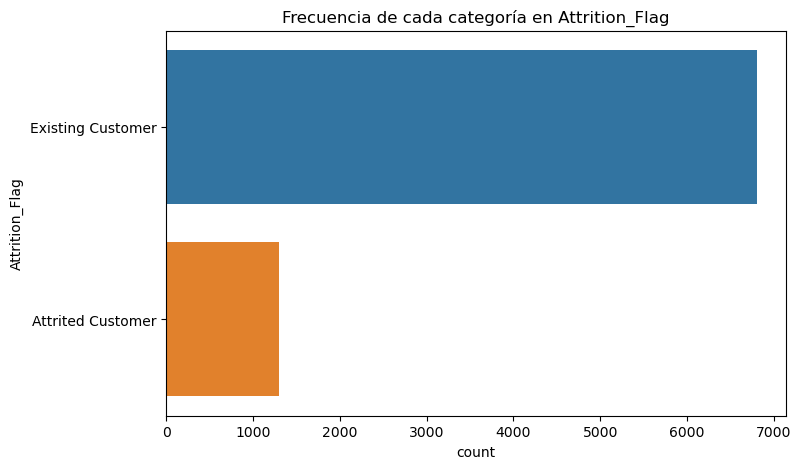

In [15]:
# Análisis univariante de la variable objetivo 'Attrition_Flag'
univariate_analysis(train_X, 'Attrition_Flag')

Este gráfico muestra un claro desbalanceo en la variable objetivo: la mayoría de los clientes pertenecen a una sola clase (`Existing Customer`), mientras que la clase minoritaria (`Attrited Customer`) está poco representada.

Este desbalanceo implica que, si entrenamos un modelo sin corregirlo, tenderá a predecir siempre la clase mayoritaria, ignorando la minoritaria. De esta forma, si mantenemos esta distribución de clientes, el modelo no será útil para detectar los casos de abandono.

Por ello, será fundamental aplicar técnicas de balanceo avanzadas antes de entrenar los modelos.

- #### **Customer_Age**

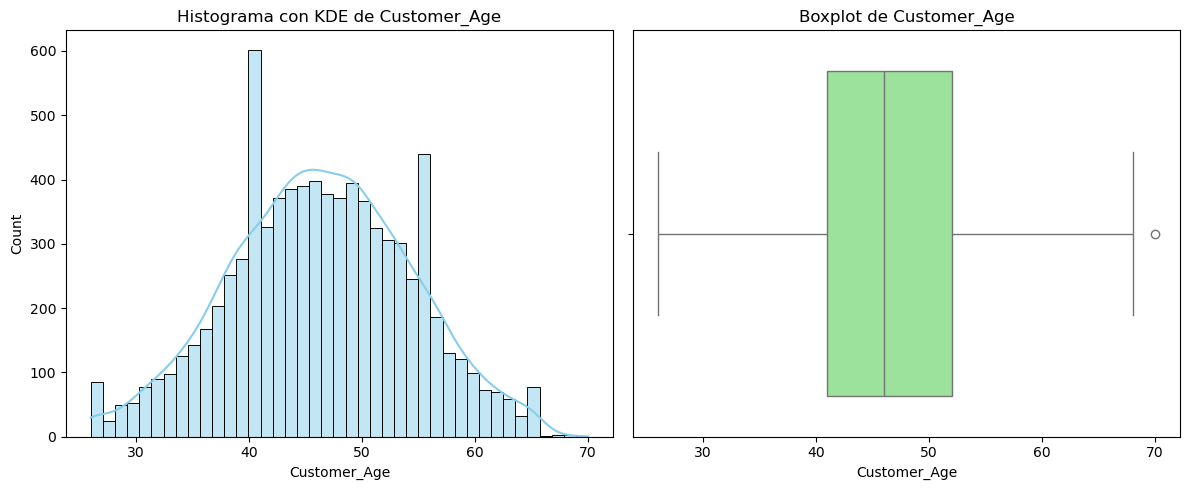

In [16]:
# Análisis univariante de la variable 'Customer_Age'
univariate_analysis(train_X, 'Customer_Age')

Respecto a la distribución de edades de los clientes, podemos apreciar que la mayoría de los clientes se concentran en un rango de edad intermedio (alrededor de 46), mostrando una distribución aproximadamente normal. Además, la mayor parte de los datos se concentran en un rango de edad de entre 41 y 52, salvo en un caso aislado (outlier) de una edad alta (70).

- #### **Gender**

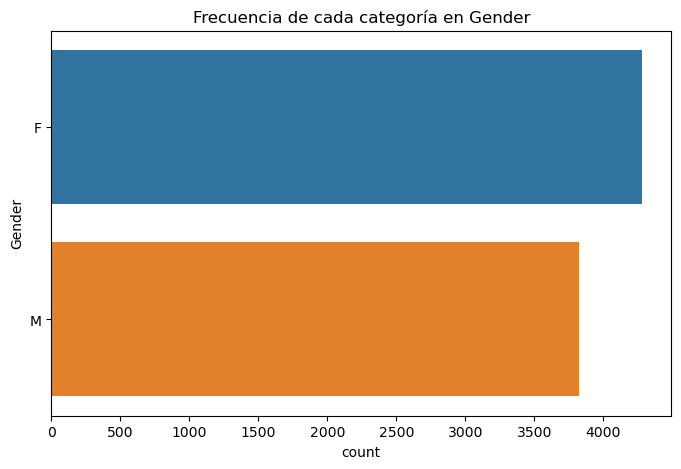

In [17]:
# Análisis univariante de la variable 'Gender'
univariate_analysis(train_X, 'Gender')

 Tenemos que hay una mayor proporción de clientas femeninas (`F`) frente a clientes masculinos (`M`).

- #### **Education_Level**

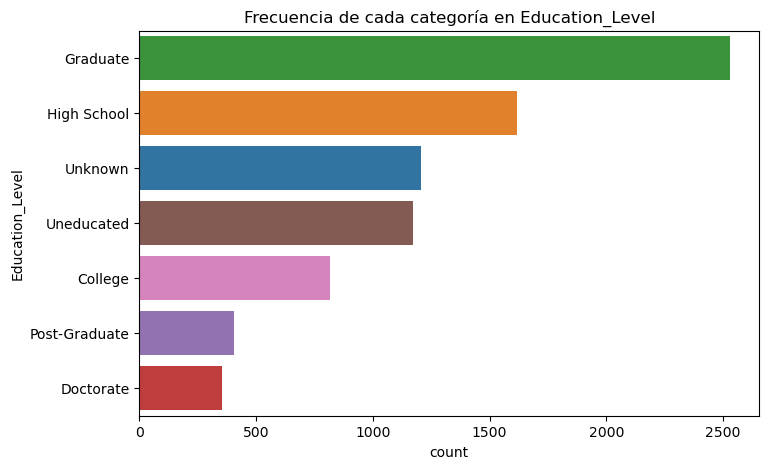

In [18]:
# Análisis univariante de la variable 'Education_Level'
univariate_analysis(train_X, 'Education_Level')

Entre las distintas categorías del nivel de educación, tenemos que las más frecuentes entre los clientes son `Graduate` y `High School`, lo que indica que la mayoría de ellos tienen estudios universitarios o de secundaria. Por otro lado, la categoría `Doctorate` es la menos representada.

- #### **Marital_Status**

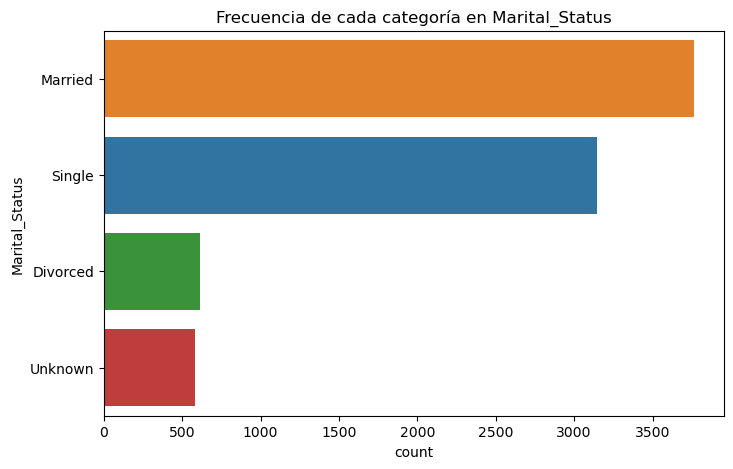

In [19]:
# Análisis univariante de la variable 'Marital_Status'
univariate_analysis(train_X, 'Marital_Status')

Respecto al estado civil del cliente, observamos que la mayoría de los clientes están casados (`Married`), seguidos por los solteros (`Single`), y en menor proporción se encuentran los clientes divorciados (`Divorced`). 

- #### **Income_Category**

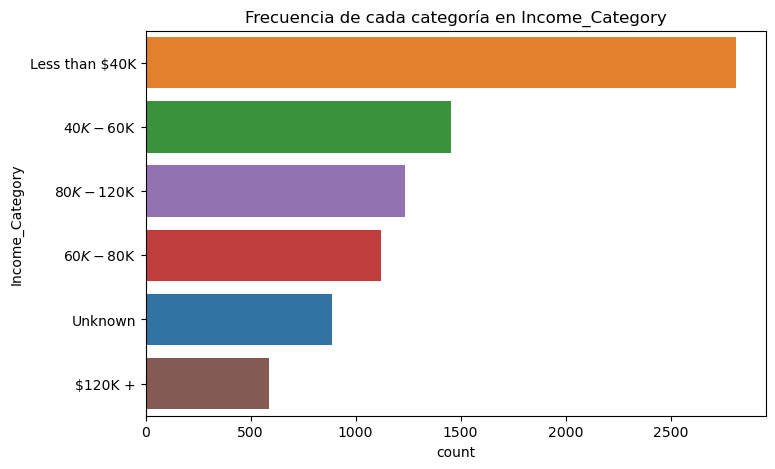

In [20]:
# Análisis univariante de la variable 'Income_Category'
univariate_analysis(train_X, 'Income_Category')

En cuanto al rango de ingresos, podemos apreciar que predominan los clientes que tienen ingresos inferiores en la categoría `Less than $40K`, mientras que la categoría menos representada es `$120K+`.

- #### **Card_Category**

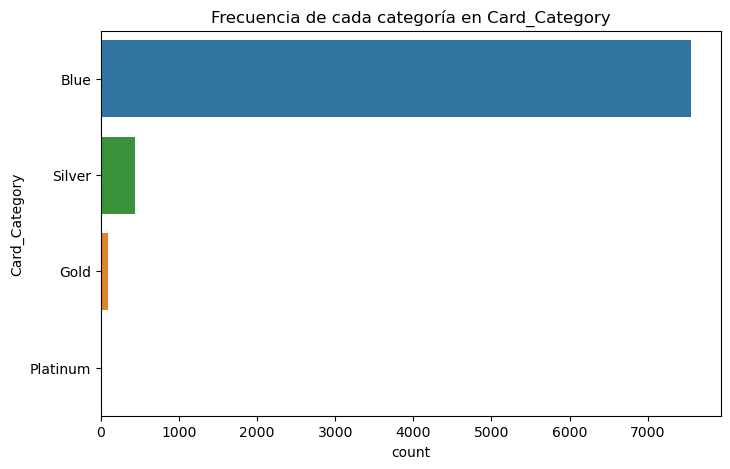

In [21]:
# Análisis univariante de la variable 'Card_Category'
univariate_analysis(train_X, 'Card_Category')

Podemos observar que la gran mayoría de los clientes utilizan la tarjeta más basica, `Blue`, mientras que las categorías superiores `Silver`, `Gold` y `Platinum` tienen una representación mucho menor. Aquí, debido al uso minoritario de las tarjetas superiores, podríamos agrupar estas categorías en una sola para simplificar el análisis.

#### **2.2.2. Penetración de la target en cada variable**

In [22]:
# Función para analizar la relación entre dos variables
def bivariate_analysis(df, var1, var2):
    for col in [var1, var2]:
        if col not in df.columns:
            print(f"La columna '{col}' no existe en el DataFrame")
            return

    # Graficamos según el tipo de variables
    tipos = {}
    for col in [var1, var2]:
        if df[col].dtype in ['int64', 'float64']:
            tipos[col] = 'num'
        elif df[col].dtype == 'object' or str(df[col].dtype) == 'category':
            tipos[col] = 'cat'
        else:
            print(f"No se puede analizar la columna '{col}' de tipo {df[col].dtype}")
            return

    # Numérica vs numérica
    if tipos[var1] == 'num' and tipos[var2] == 'num':
        plt.figure(figsize=(7, 5))
        sns.scatterplot(x=var1, y=var2, data=df, color='skyblue')
        plt.title(f"Relación entre {var1} y {var2}")
        plt.show()

    # Numérica vs categórica
    elif (tipos[var1] == 'num' and tipos[var2] == 'cat') or (tipos[var1] == 'cat' and tipos[var2] == 'num'):
        # Asegurar que num_var esté primero
        num_var = var1 if tipos[var1]=='num' else var2
        cat_var = var2 if tipos[var1]=='num' else var1

        plt.figure(figsize=(8, 5))
        sns.boxplot(x=cat_var, y=num_var, data=df, palette='pastel', hue=cat_var, legend=False)
        plt.title(f"Distribución de {num_var} por {cat_var}")
        plt.show()

    # Categórica vs categórica
    elif tipos[var1] == 'cat' and tipos[var2] == 'cat':
        cross_tab = pd.crosstab(df[var1], df[var2])
        cross_tab_percent = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

        plt.figure(figsize=(8, 6))
        sns.heatmap(cross_tab_percent, annot=True, fmt=".2f", cmap='coolwarm_r', cbar_kws={'format': '%.0f%%'})
        plt.title(f"Frecuencia relativa (%) entre {var1} y {var2}")
        plt.ylabel(var1)
        plt.xlabel(var2)
        plt.show()

- #### **Card_Category vs Attrition_Flag**

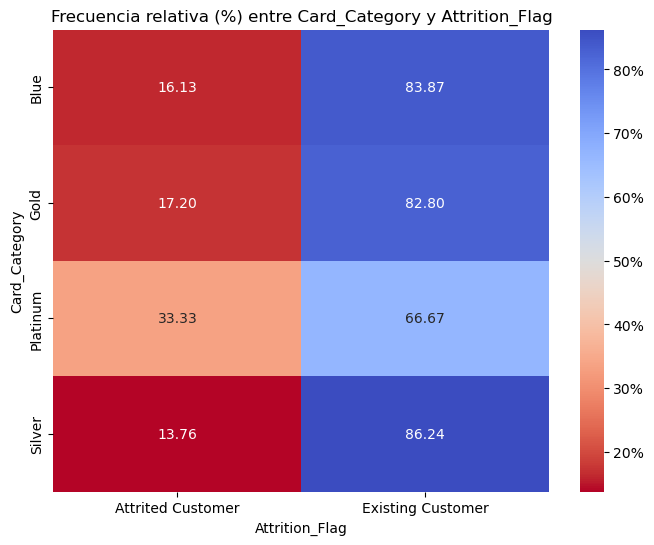

In [23]:
# Análisis bivariado entre 'Card_Category' y 'Attrition_Flag'
bivariate_analysis(train_X,'Card_Category', 'Attrition_Flag')

El gráfico de calor muestra la probabilidad de que un cliente abandone o permanezca en función de la categoría de tarjeta que utilice. No se observa una diferencia significativa en la probabilidad de abandono entre las distintas categorías de tarjeta, pues, independientemente de la tarjeta, la mayoría de los clientes tienden a permanecer.

Por tanto, la variable `Card_Category` no tiene una influencia significativa sobre el abandono del cliente.

- #### **Gender vs Attrition_Flag**

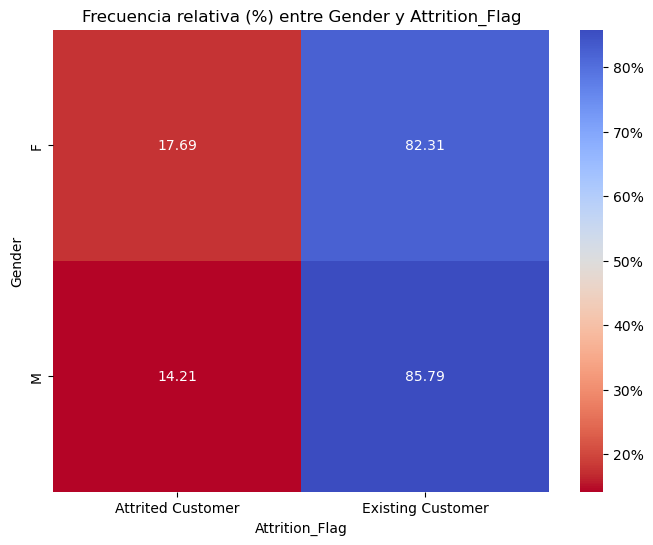

In [24]:
# Análisis bivariado entre 'Gender' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Gender', 'Attrition_Flag')

Aquí, las proporciones de abandono son similares entre hombres y mujeres, por lo que la variable `Gender` no tiene un impacto relevante en la predicción de abandono.

- #### **Education_Level vs Attrition_Flag**

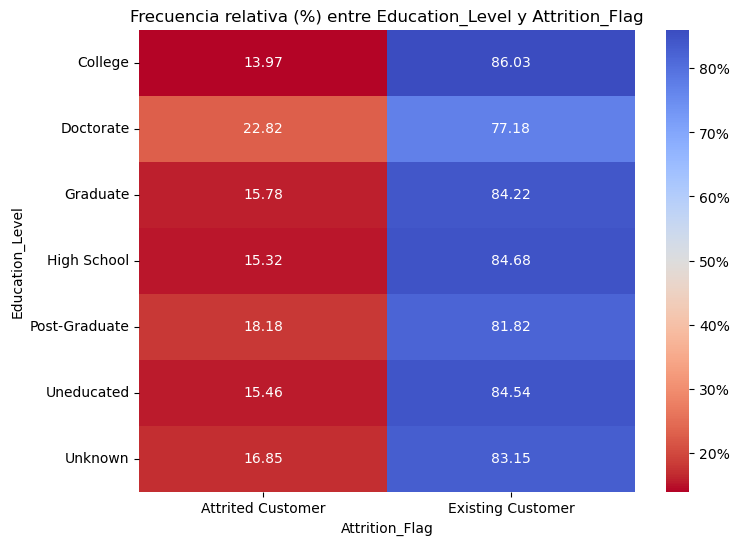

In [25]:
# Análisis bivariado entre 'Education_Level' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Education_Level', 'Attrition_Flag')

Nuevamente, las tasas de abandono son similares entre los distintos niveles educativos, por lo que la variable `Education_Level` no tiene una influencia significativa sobre el abandono del cliente.

- #### **Marital_Status vs Attrition_Flag**

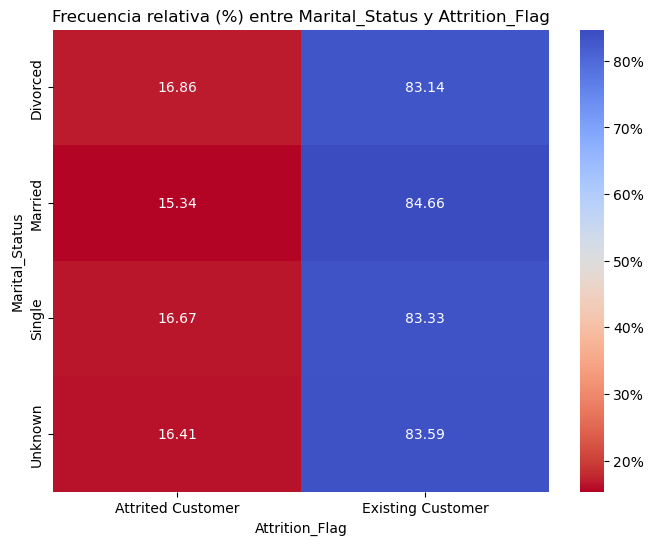

In [26]:
# Análisis bivariado entre 'Marital_Status' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Marital_Status', 'Attrition_Flag')

No hay diferencias significativas en la tasa de abandono entre los distintos estados civiles, por lo que la variable `Marital_Status` no tiene un impacto relevante en la predicción de abandono.

- #### **Income_Category vs Attrition_Flag**

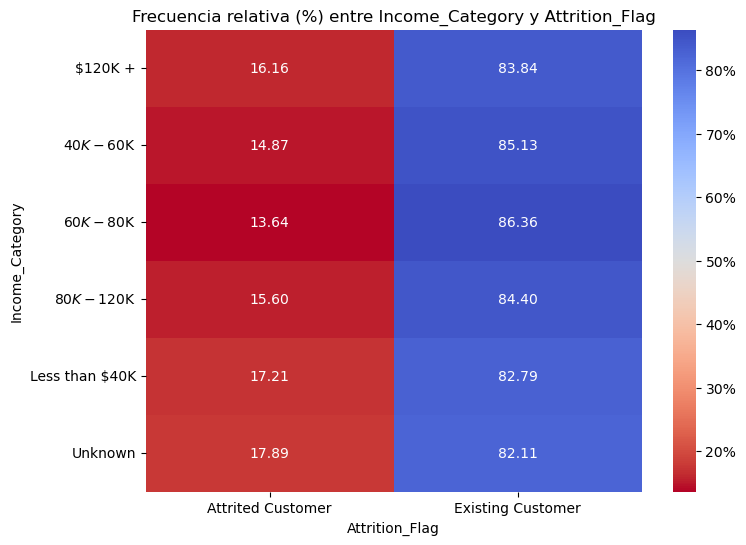

In [27]:
# Análisis bivariado entre 'Income_Category' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Income_Category', 'Attrition_Flag')

No se observa una diferencia significativa en la tasa de abandono entre las distintas categorías de ingresos, por lo que la variable `Income_Category` tiene un impacto poco relevante sobre el abandono del cliente.

- #### **Customer_Age vs Attrition_Flag**

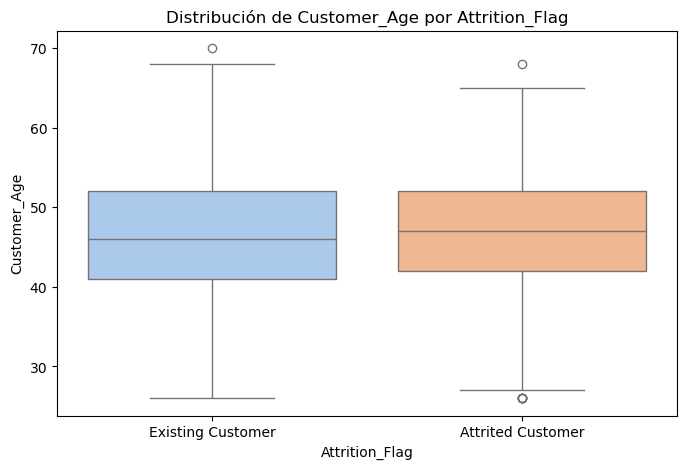

In [28]:
# Análisis bivariado entre 'Customer_Age' y 'Attrition_Flag'
bivariate_analysis(train_X,'Customer_Age', 'Attrition_Flag')

En este boxplot, observamos que la mediana y el rango intercuartílico de la edad son bastante similares entre los clientes que permanecen y los que abandonan. Además, no se observa una concentración clara de outliers en una clase concreta.

Por tanto, la variable `Customer_Age` tampoco parece ser un factor determinante para el abandono.

- #### **Avg_Open_To_Buy vs Attrition_Flag**

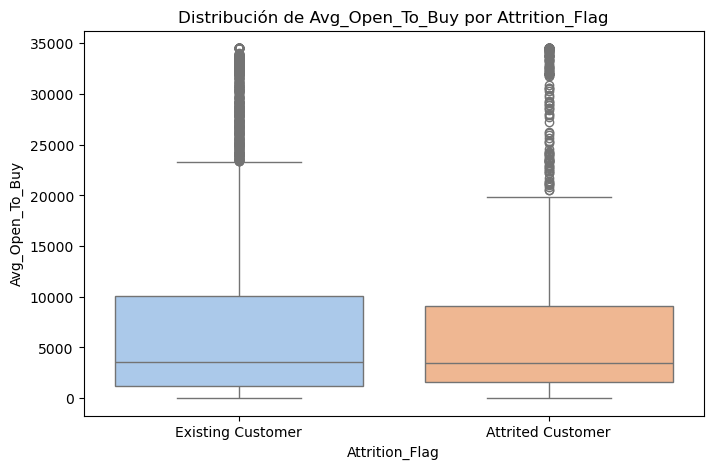

In [29]:
# Análisis bivariado entre 'Avg_Open_To_Buy' y 'Attrition_Flag'
bivariate_analysis(train_X,'Avg_Open_To_Buy', 'Attrition_Flag')

Aquí, la distribución del promedio de crédito disponible es prácticamente la misma para los clientes que permanecen y los que abandonan. Las medianas y los rangos intercuartílicos son similares entre ambas clases, lo que indica que tener más o menos crédito disponible no parece influir en la decisión de abandonar el banco.

Por tanto, la variable `Avg_Open_To_Buy` no parece tener relevancia en la predicción del abandono.


- #### **Total_Trans_Ct vs Attrition_Flag**

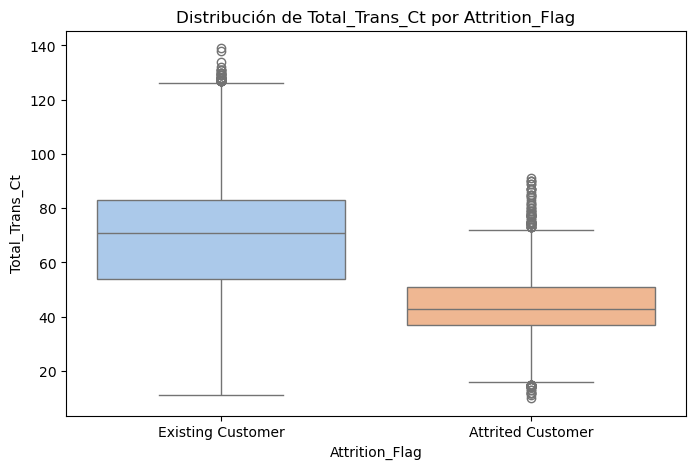

In [30]:
# Análisis bivariado entre 'Total_Trans_Ct' y 'Attrition_Flag'
bivariate_analysis(train_X,'Total_Trans_Ct', 'Attrition_Flag')


En este caso, la distribución del número total de transacciones es claramente diferente entre los clientes que permanecen y los que abandonan. Los clientes que permanecen presentan medianas y rangos intercuartílicos mucho más altos, mientras que los que abandonan tienen valores significativamente más bajos. Esto significa que los clientes que hagan más transacciones son más probables a que se queden, mientras que los que hagan menos tienden a irse, lo cual es bastante lógico.

Por tanto, la variable `Total_Trans_Ct`, sí que parece influir en la decisión de abandonar el banco.

- #### **Dependent_count vs Attrition_Flag**

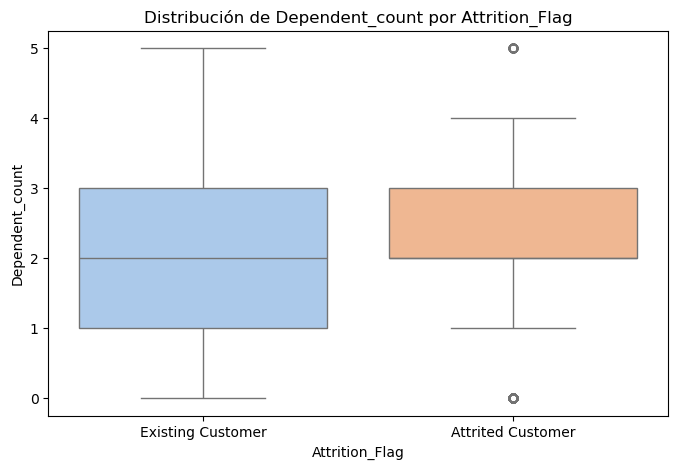

In [31]:
# Análisis bivariado entre 'Dependent_count' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Dependent_count', 'Attrition_Flag')

Se observa un solapamiento considerable entre ambos grupos, lo que indica que la variable `Dependent_Count` no diferencia claramente entre los clientes que permanecen y los que abandonan. La mayoría de los clientes que permanecen tienen entre 1 y 3 dependientes, mientras que los que abandonan se concentran principalmente entre 2 y 3 dependientes. Esto sugiere que el número de dependientes no parece ser un factor determinante en la decisión de abandono.

- #### **Months_on_Book vs Attrition_Flag**

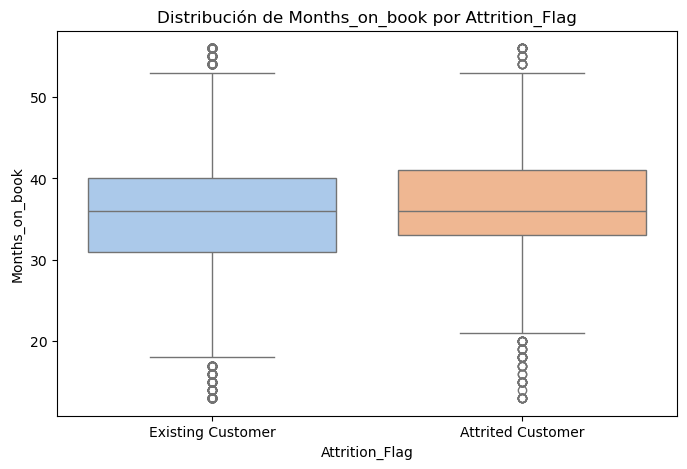

In [32]:
# Análisis bivariado entre'Months_on_book' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Months_on_book', 'Attrition_Flag')

En este caso, se observa que ambos grupos presentan rangos intercuartílicos muy similares, aproximadamente entre 31 y 40 meses. La mediana es prácticamente igual para ambos, lo que indica que la antigüedad del cliente en el banco no muestra diferencias claras entre los que abandonan y los que permanecen. 

Por tanto, la variable `Months_on_book`, no parece tener relevancia en la predicción del abandono.


- #### **Total_Relationship_Count vs Attrition_Flag**

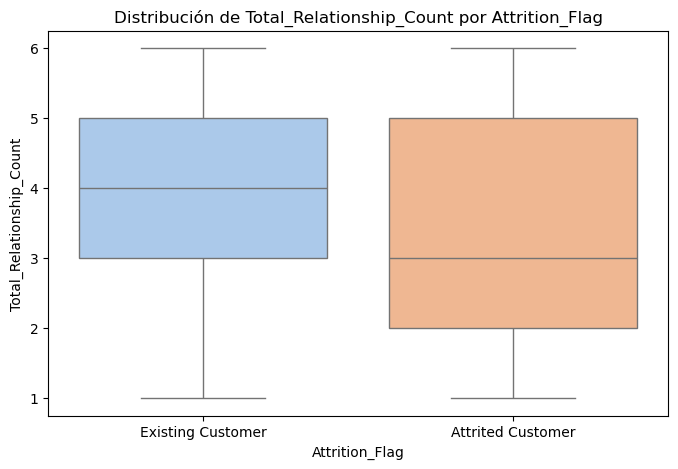

In [33]:
# Análisis bivariado entre 'Total_Relationship_Count' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Total_Relationship_Count', 'Attrition_Flag')

Aunque los clientes que permanecen tienden a tener un número ligeramente mayor de productos contratados (mediana 4 vs 3), el solapamiento con los clientes que abandonan es considerable. Esto indica que la variable `Total_Relationship_Count` no parece ser un factor claramente significativo para predecir churn por sí solo.

- #### **Months_Inactive_12_mon vs Attrition_Flag**

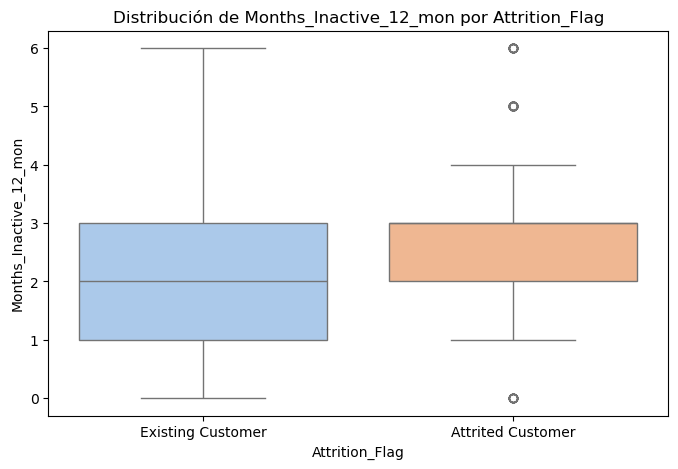

In [34]:
# Análisis bivariado entre 'Months_Inactive_12_mon' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Months_Inactive_12_mon', 'Attrition_Flag')

Se observa un solapamiento considerable entre ambos grupos. Los clientes que permanecen tienen un rango de meses inactivos entre 1 y 3, mientras que los que abandonan se concentran entre 2 y 3 meses. Además, destaca la presencia de tres outliers en el grupo de clientes que abandonan, con valores de inactividad superiores al rango habitual, mientras que en el grupo de clientes existentes no hay outliers.

Sin embargo, aunque haya presencia de esos valores atípicos, la variable `Months_Inactive_12_mon` no parece ser un factor determinante sobre el abandono del cliente.

- #### **Contacts_Count_12_mon vs Attrition_Flag**

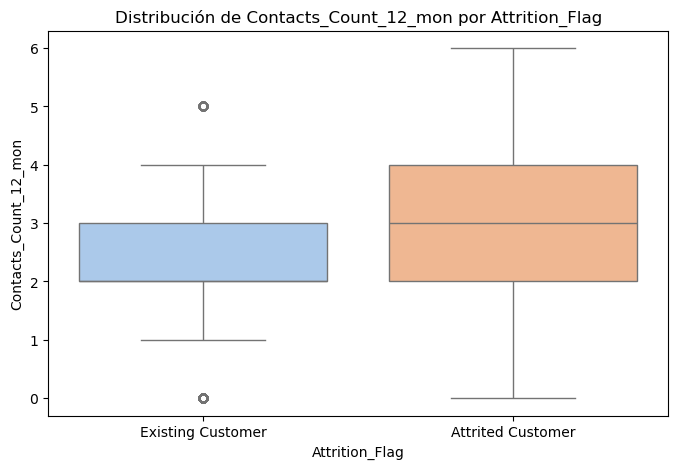

In [35]:
# Análisis bivariado entre 'Contacts_Count_12_mon' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Contacts_Count_12_mon', 'Attrition_Flag')

Aquí, se observa que los clientes que permanecen tienden a tener un mayor número de contactos con el banco en el último año, con un rango intercuartílico y una mediana superiores respecto a los clientes que abandonan, lo que indica que la interacción con el banco podría relacionarse con la retención. Sin embargo, debido al solapamiento y a que la variable `Contacts_Count_12_mon` mide solo un periodo concreto, su influencia es relevante pero no determinante.

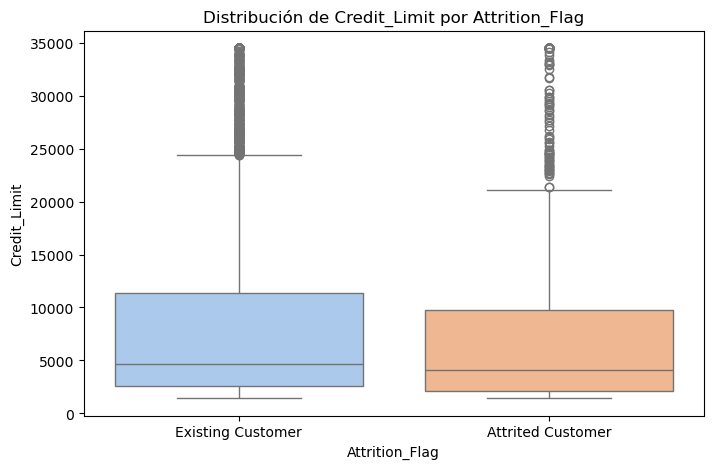

In [36]:
# Análisis bivariado entre 'Credit_Limit' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Credit_Limit', 'Attrition_Flag')



En este caso, se observa que ambos grupos presentan rangos intercuartílicos muy similares en el límite de crédito, con una mediana prácticamente igual para clientes que permanecen y los que abandonan. Esto indica que el límite de crédito no muestra diferencias claras entre los dos grupos.

Por tanto, la variable `Credit_Limit` no parece tener relevancia en la predicción del abandono.

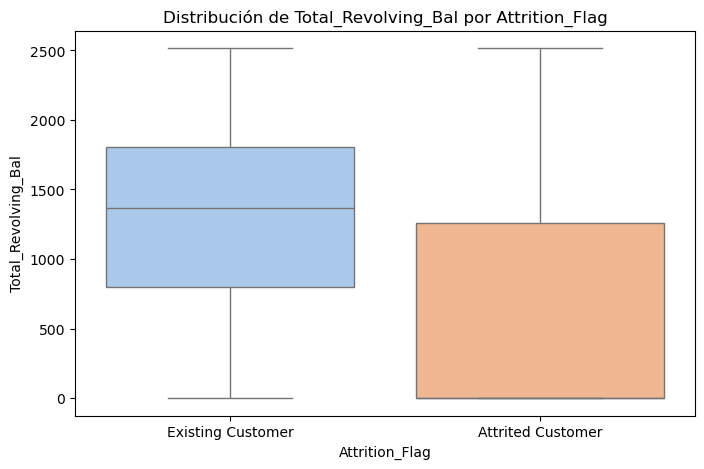

In [37]:
# Análisis bivariado entre 'Total_Revolving_Bal' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Total_Revolving_Bal', 'Attrition_Flag')

Aquí, la distribución de los fondos totales utilizados es claramente diferente entre los clientes que permanecen y los que abandonan. Los clientes que permanecen presentan medianas y rangos intercuartílicos más altos, mientras que los que abandonan tienen valores más bajos. Esto significa que los clientes con mayor uso de fondos son más propensos a quedarse, mientras que los que no lo usan tanto tienden a irse.

Por tanto, la variable `Total_Revolving_Bal` sí que parece influir en la decisión de abandonar el banco.

- #### **Avg_Utilization_Ratio vs Attrition_Flag**

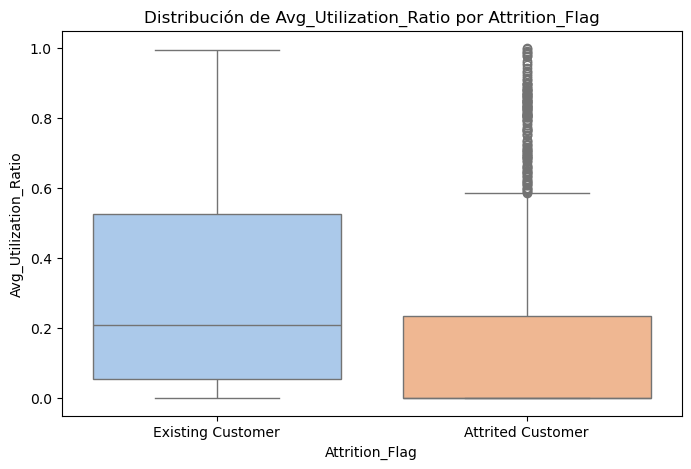

In [38]:
# Análisis bivariado entre 'Avg_Utilization_Ratio' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Avg_Utilization_Ratio', 'Attrition_Flag')

El boxplot muestra que los clientes que permanecen en el banco suelen tener un ratio de utilización promedio de su crédito entre 0.1 y 0.5, sin valores atípicos destacados, lo que refleja un uso moderado y controlado de su tarjeta. Por el contrario, los clientes que abandonan presentan mayor concentración en ratios bajos (< 0.2), pero también existen muchos casos atípicos con ratios muy altos (> 0.6). Esto indica que el abandono se asocia tanto a un uso muy bajo como a un uso extremo del crédito, lo que puede reflejar desinterés o comportamientos de riesgo.

Por tanto, el `Avg_Utilization_Ratio` parece ser una variable relevante para predecir el abandono de clientes.

- #### **Total_Trans_Amt vs Attrition_Flag**

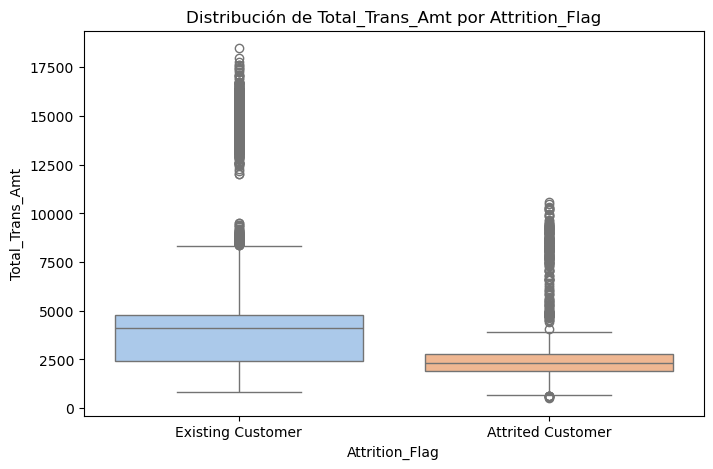

In [39]:
# Análisis bivariado entre 'Total_Trans_Amt' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Total_Trans_Amt', 'Attrition_Flag')

Se observa que los clientes que permanecen en el banco suelen realizar un mayor volumen de transacciones y presentan una mayor dispersión en sus montos, mientras que los clientes que abandonan muestran una actividad transaccional más baja y homogénea. Esto indica que los clientes menos activos tienen mayor probabilidad de abandonar, mientras que los más activos tienden a permanecer. 

Por tanto, `Total_Trans_Amt` tiene una influencia significativa en la predicción del churn.

- #### **Total_Amt_Chng_Q4_Q1 vs Attrition_Flag**

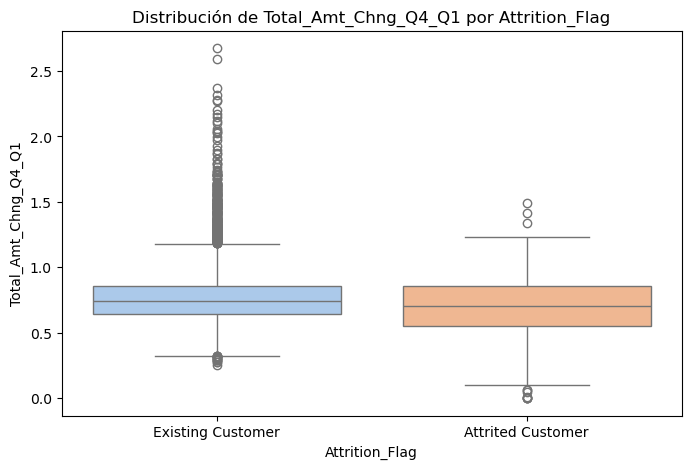

In [40]:
# Análisis bivariado entre 'Total_Amt_Chng_Q4_Q1' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Total_Amt_Chng_Q4_Q1', 'Attrition_Flag')

El boxplot muestra que tanto los clientes que permanecen como los que abandonan presentan distribuciones muy similares en el incremento del importe de transacciones entre el cuarto y el primer trimestre, con medianas y rangos prácticamente iguales. No obstante, en los clientes que permanecen hay una mayor cantidad de outliers hacia valores altos, lo que indica que algunos de ellos han experimentado aumentos inusuales en sus transacciones. Aun así, la variable `Total_Amt_Chng_Q4_Q1` no diferencia claramente entre los grupos, por lo que su utilidad para predecir el churn es limitada.

- #### **Total_Ct_Chng_Q4_Q1 vs Attrition_Flag**

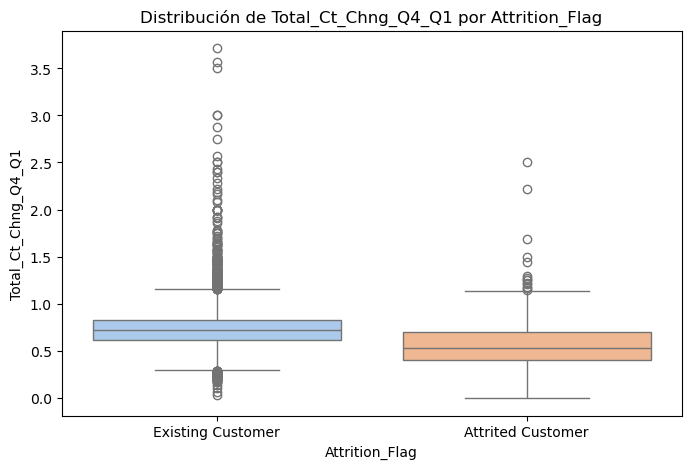

In [41]:
# Análisis bivariado entre 'Total_Ct_Chng_Q4_Q1' y 'Attrition_Flag'
bivariate_analysis(train_X, 'Total_Ct_Chng_Q4_Q1', 'Attrition_Flag')

 En este caso, se observa que los clientes que permanecen en el banco presentan un mayor incremento en el número de transacciones entre el cuarto y el primer trimestre, y una mayor dispersión, mientras que los clientes que abandonan tienen valores más bajos y homogéneos, con una mediana inferior. Esto indica que una menor variación en la cantidad de transacciones está asociada a una mayor probabilidad de abandono, mientras que los clientes más activos y con mayor variabilidad tienden a permanecer. 

Por tanto, `Total_Ct_Chng_Q4_Q1` sí parece tener una influencia significativa sobre el abandono del cliente.

### **2.3. Correlación entre variables**

En este apartado, nuestro objetivo es reducir la redundancia entre variables altamente correlacionadas para que el modelo sea más simple, estable y fácil de interpretar. Para ello, haremos lo siguiente:

- **Analizar la correlación entre variables:** Identificaremos pares de variables con correlación muy alta (por ejemplo, >0.80). Estas variables aportarían información muy similar, por lo que mantener ambas podría ser redundante.

- **Evaluar la relación con la variable objetivo:** Entre las variables correlacionadas, nos quedaremos con la que tenga mayor capacidad predictiva sobre el churn (Attrition_Flag). Esto asegura que conservemos la información más relevante para predecir la retención de clientes.

- **Considerar la distribución individual de cada variable:** Si varias variables aportan información similar y su relación con el churn es comparable, elegiremos la que tenga mejor distribución de los datos.

In [42]:
# Función para graficar la matriz de correlación de variables numéricas
def plot_correlation_matrix(df, method='spearman'):
    # Seleccionamos solo variables numéricas
    numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

    if len(numerical_cols) > 1:
        # Calculamos la matriz de correlación
        corr_matrix = df[numerical_cols].corr(method=method)

        # Visualizamos la matriz de correlación como un heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': .8})
        plt.title('Matriz de Correlación de Variables Numéricas')
        plt.show()

    else:
        print("No hay suficientes variables numéricas para calcular correlaciones.")

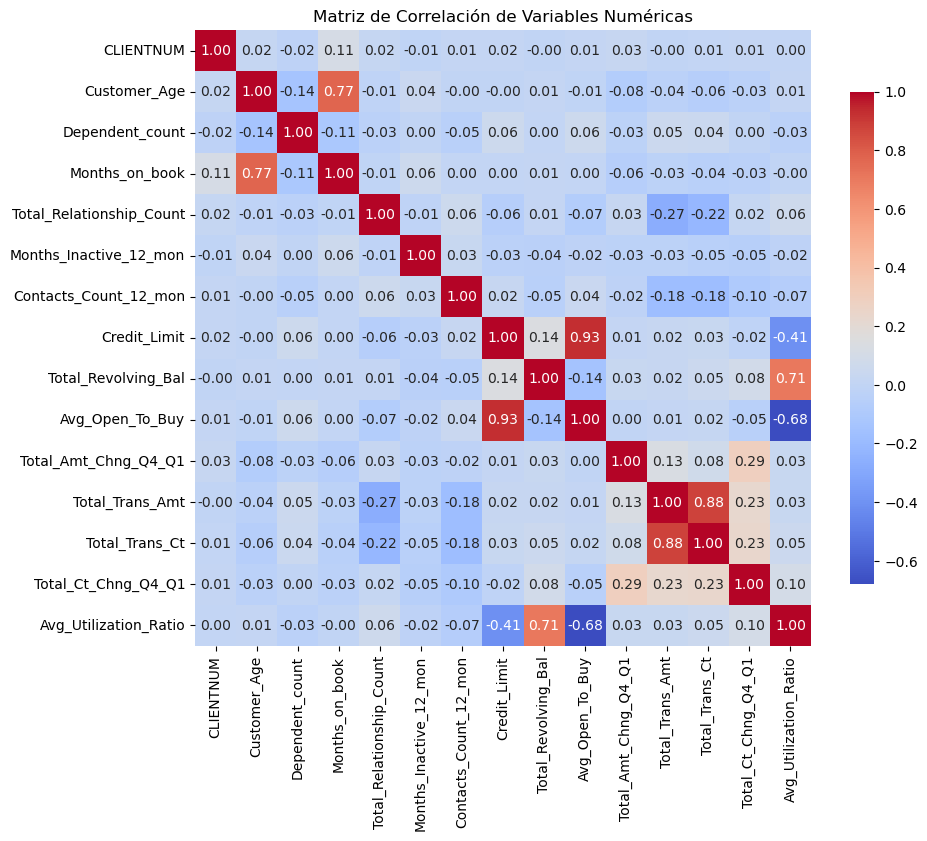

In [43]:
# Visualizamos la matriz de correlaciones entre todas las variables numéricas de train_X
plot_correlation_matrix(train_X)

Se observa una alta correlación positiva entre `Total_Trans_Ct` y `Total_Trans_Amt` (0.93): a mayor número de transacciones, mayor suele ser el importe total transaccionado. Para evitar esto, tendremos que quedarnos con una de las dos.

Además, las variables `Credit_Limit` y `Avg_Open_To_Buy` presentan una fuerte correlación (0.88): más límite de crédito implica más crédito disponible. También tendremos que quedarnos con una.

El resto de las variables no presentan correlaciones extremadamente altas entre sí.

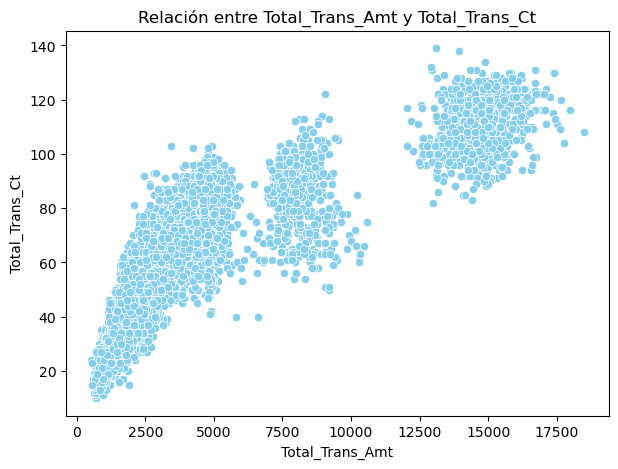

In [44]:
# Visualizamos la relación entre 'Total_Trans_Amt' y 'Total_Trans_Ct'
bivariate_analysis(train_X,'Total_Trans_Amt', 'Total_Trans_Ct')

In [45]:
def bivariate_analysis_ax(df, var1, var2, ax):
    # Identificamos tipos de variables
    tipos = {}
    for col in [var1, var2]:
        if df[col].dtype in ['int64', 'float64']:
            tipos[col] = 'num'
        elif df[col].dtype == 'object' or str(df[col].dtype) == 'category':
            tipos[col] = 'cat'
        else:
            raise ValueError(f"No se puede analizar la columna '{col}' de tipo {df[col].dtype}")

    # Solo para numérica vs categórica
    num_var = var1 if tipos[var1]=='num' else var2
    cat_var = var2 if tipos[var1]=='num' else var1
    sns.boxplot(x=cat_var, y=num_var, data=df, palette='pastel', hue=cat_var,
                legend=False, ax=ax)
    ax.set_title(f"Distribución de {num_var} por {cat_var}")
    ax.set_xlabel(cat_var)
    ax.set_ylabel(num_var)

In [46]:
# Función para comparar dos variables correlacionadas
def compare_correlated_vars(df, var1, var2, target):
    fig, axes = plt.subplots(1, 2, figsize=(12, 7))
    bivariate_analysis_ax(df, var1, target, ax=axes[0])
    bivariate_analysis_ax(df, var2, target, ax=axes[1])
    plt.tight_layout()
    plt.show()


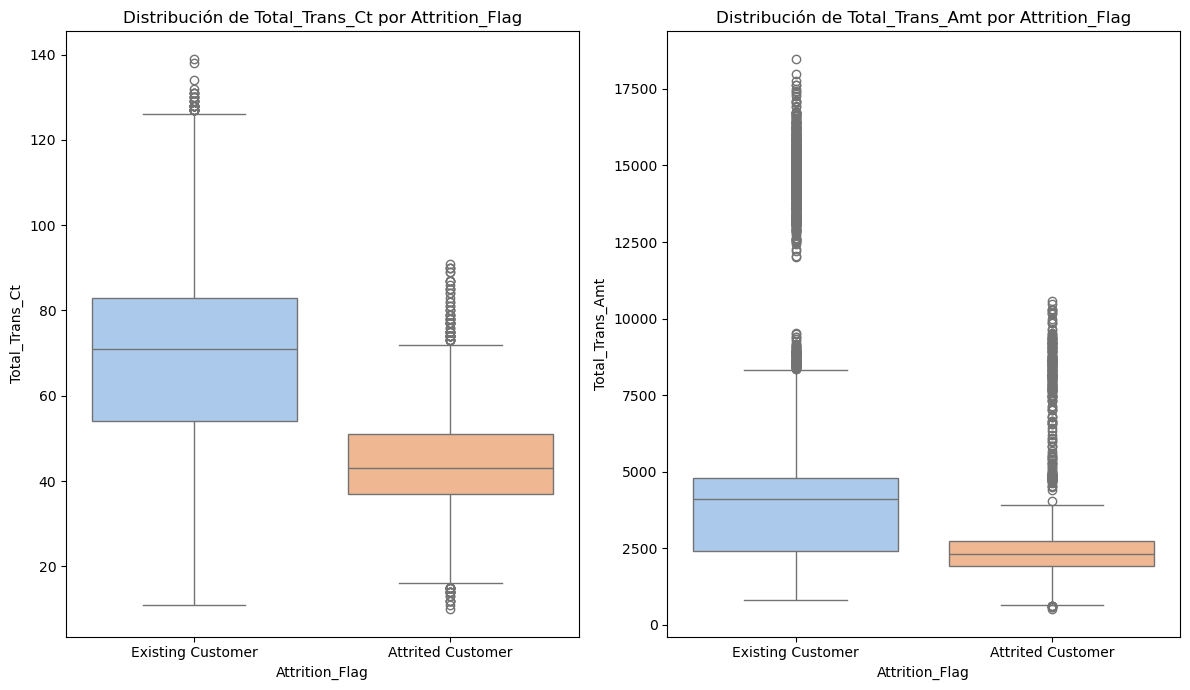

In [47]:
# Comparación entre 'Total_Trans_Ct' y 'Total_Trans_Amt' respecto a 'Attrition_Flag'
compare_correlated_vars(train_X, 'Total_Trans_Ct', 'Total_Trans_Amt', 'Attrition_Flag')

Ambas variables muestran una relación clara con el churn, ya que en los boxplots se observa una diferenciación entre los clientes que se quedan y los que abandonan. No obstante, la variable `Total_Trans_Ct` presenta una separación más marcada entre ambas clases, lo que indica que parece tener una mayor influencia en la decisión de abandono.

Para tomar un decisión definita de qué variable es mejor quedarse, tomaremos en cuenta también cuál de las dos está mejor distribuida individualmente:

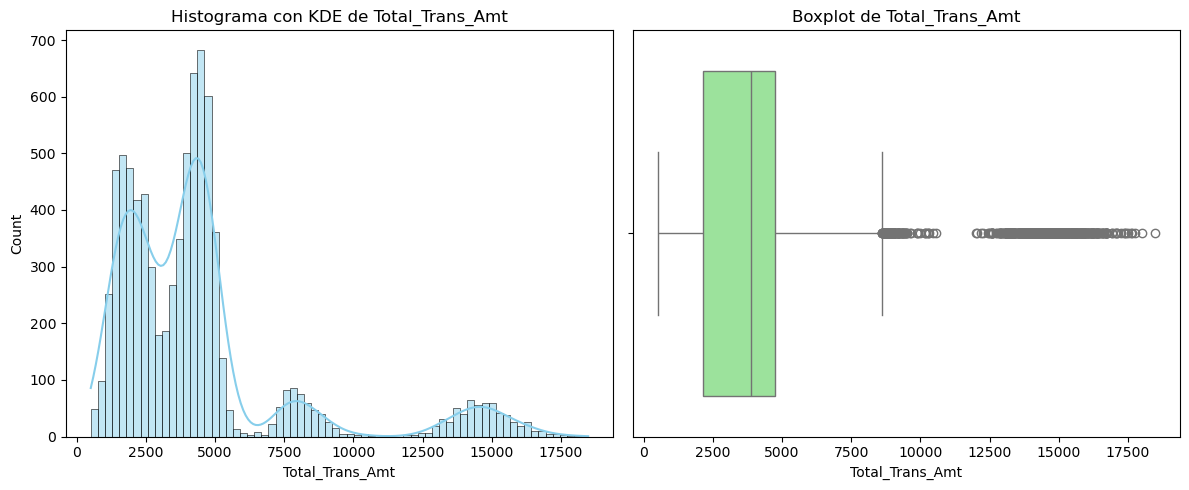

In [48]:
# Análisis univariante de la variable 'Total_Trans_Amt'
univariate_analysis(train_X, 'Total_Trans_Amt')

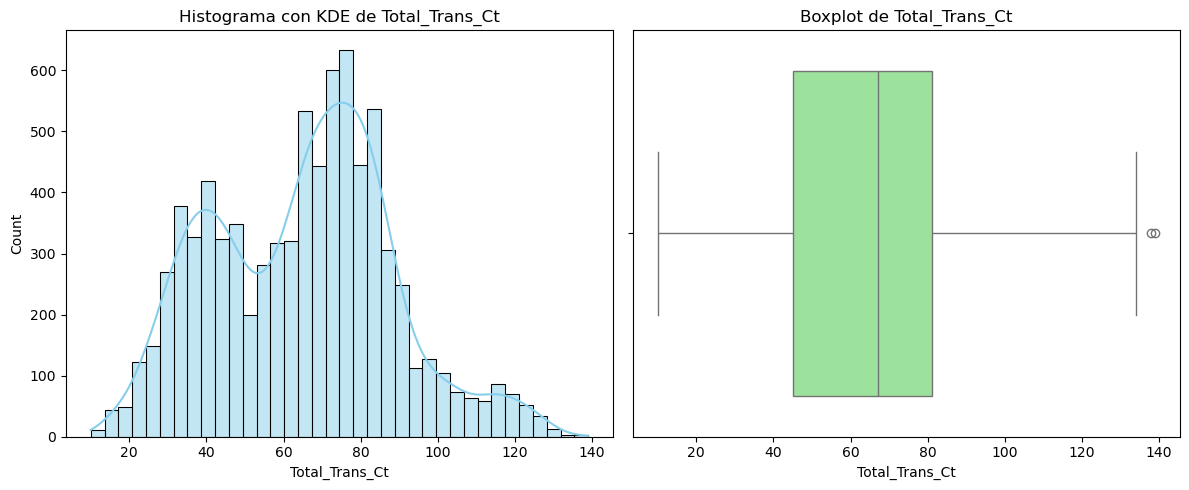

In [49]:
# Análisis univariante de la variable 'Total_Trans_Ct'
univariate_analysis(train_X, 'Total_Trans_Ct')

Al analizar la distribución individual de las variables, se observa que `Total_Trans_Ct` está mejor distribuida, con menos concentración de valores extremos y una forma más estable. Por este motivo, nos quedaremos con esta variable y descartaremos la variable `Total_Trans_Amt`, ya que captura mejor el comportamiento general de los clientes.

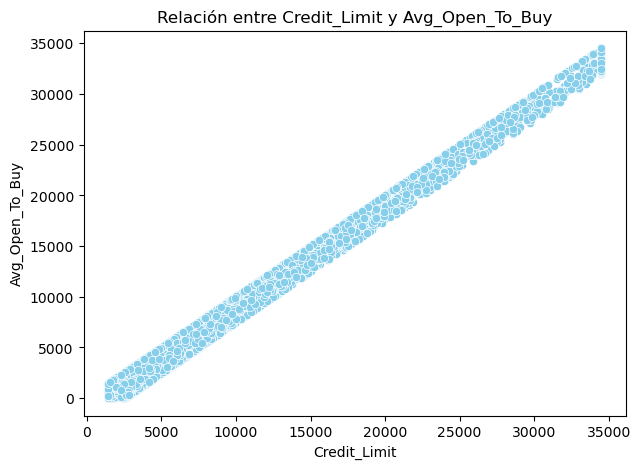

In [50]:
# Visualizamos la relación entre 'Credit_Limit' y 'Avg_Open_To_Buy'
bivariate_analysis(train_X,'Credit_Limit', 'Avg_Open_To_Buy')

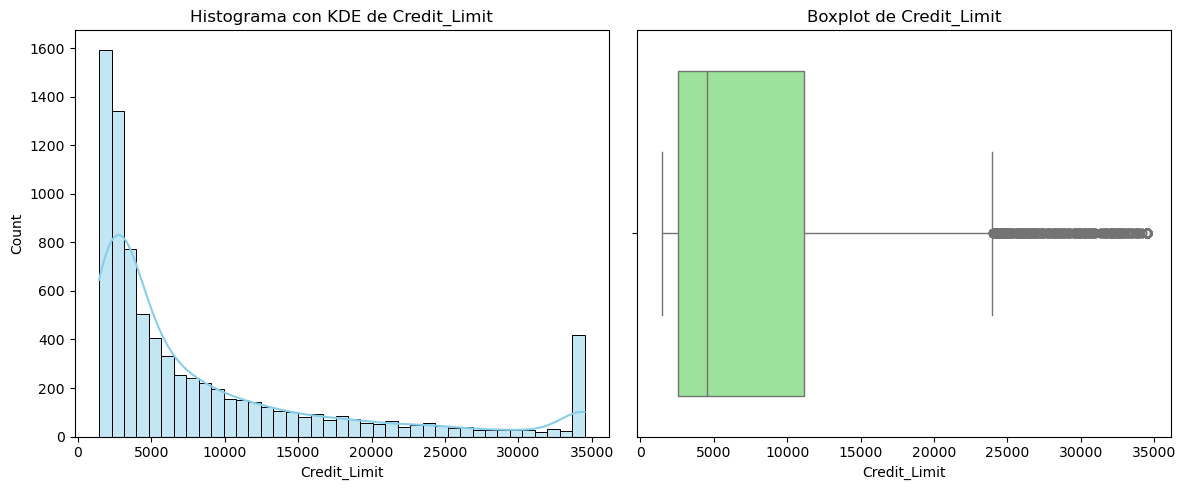

In [51]:
# Análisis univariante de la variable 'Credit_Limit'
univariate_analysis(train_X, 'Credit_Limit')

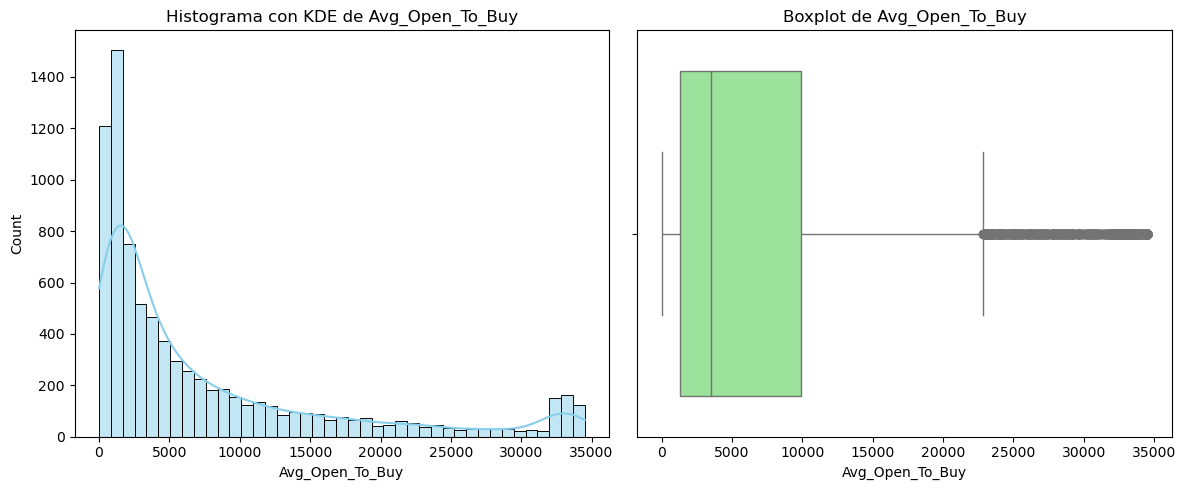

In [52]:
# Análisis univariante de la variable 'Avg_Open_To_Buy'
univariate_analysis(train_X, 'Avg_Open_To_Buy')

Al mirar la distribución individual de cada variable, ambas presentan un comportamiento muy similar, por lo que no hay diferencias significativas en cómo se distribuyen los datos.

Nuevamente, para tomar un decisión definita de qué variable es mejor quedarse, tomaremos en cuenta cuál de las dos variables puede tener un mayor impacto sobre el churn:

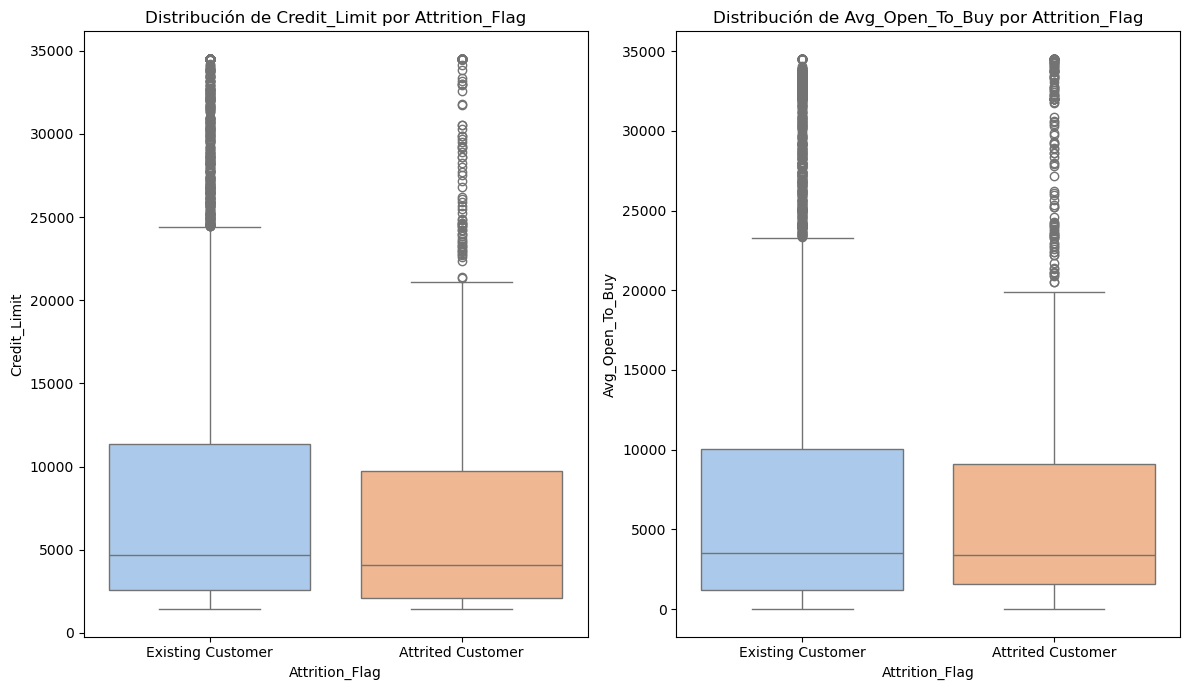

In [53]:
# Comparación entre 'Credit_Limit' y 'Avg_Open_To_Buy' respecto a 'Attrition_Flag'
compare_correlated_vars(train_X, 'Credit_Limit', 'Avg_Open_To_Buy', 'Attrition_Flag')

En este caso, se observa que la mediana de la variable `Credit_Limit` está ligeramente más alta para los clientes que abandonan, lo que sugiere que podría tener un impacto ligeramente mayor sobre el churn.

En consecuencia, aunque cualquiera de las dos podría ser utilizada en el modelo, nos quedaremos con la variable `Credit_Limit`, ya que parece más determinante para predecir el abandono de clientes.

# **3️⃣ Preprocesamiento**

En esta fase nos enfocaremos en preparar los datos para que sean adecuados para el modelado. Lo que haremos concretamente será:

- **Eliminación de columnas innecesarias:** removeremos variables que no aportan al análisis o que podrían generar ruido, como identificadores únicos o columnas redundantes.

- **Manejo de valores nulos o faltantes:** decidirimos si imputamos los datos usando estrategias como la media, mediana o lógica de negocio, o si eliminamos filas/columnas según la cantidad de valores faltantes.

- **Conversión de variables categóricas:** transformaremos variables categóricas (como estado civil u ocupación) en representaciones numéricas mediante técnicas como **One-Hot Encoding**.

### **3.1. Eliminar variables**

In [54]:
#Volvemos a inspeccionar el dataset
train_X.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
9066,713071383,Existing Customer,54,F,1,Unknown,Single,Unknown,Blue,36,...,3,3,3723.0,1728,1995.0,0.595,8554,99,0.678,0.464
5814,714246333,Attrited Customer,58,F,4,High School,Married,Unknown,Blue,48,...,4,3,5396.0,1803,3593.0,0.493,2107,39,0.393,0.334
792,718206783,Existing Customer,45,F,4,Unknown,Single,Less than $40K,Gold,36,...,1,3,15987.0,1648,14339.0,0.732,1436,36,1.250,0.103
1791,721096983,Existing Customer,34,F,2,Graduate,Single,Less than $40K,Blue,36,...,3,4,3625.0,2517,1108.0,1.158,2616,46,1.300,0.694
5011,720028683,Existing Customer,49,F,2,High School,Married,$40K - $60K,Blue,39,...,3,4,2720.0,1926,794.0,0.602,3806,61,0.794,0.708


Como podemos observar, la variable `CLIENTNUM` no aporta información relevante al análisis, ya que se trata únicamente de un identificador de cliente y no tiene capacidad predictiva. Por este motivo, la eliminaremos del dataset.

Además, eliminaremos las variables `Avg_Open_To_Buy` y `Total_Trans_Amt`, que previamente habíamos identificado como altamente correlacionadas con otras variables.

In [55]:
# Eliminación de columnas innecesarias
train_X.drop(columns=['CLIENTNUM','Avg_Open_To_Buy', 'Total_Trans_Amt'], inplace=True)

In [56]:
train_X.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
9066,Existing Customer,54,F,1,Unknown,Single,Unknown,Blue,36,1,3,3,3723.0,1728,0.595,99,0.678,0.464
5814,Attrited Customer,58,F,4,High School,Married,Unknown,Blue,48,1,4,3,5396.0,1803,0.493,39,0.393,0.334
792,Existing Customer,45,F,4,Unknown,Single,Less than $40K,Gold,36,6,1,3,15987.0,1648,0.732,36,1.250,0.103
1791,Existing Customer,34,F,2,Graduate,Single,Less than $40K,Blue,36,4,3,4,3625.0,2517,1.158,46,1.300,0.694
5011,Existing Customer,49,F,2,High School,Married,$40K - $60K,Blue,39,5,3,4,2720.0,1926,0.602,61,0.794,0.708


### **3.2. Tratar valores nulos**

In [57]:
# Comprobamos la cantidad de valores nulos en cada columna
train_X.isna().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [58]:
# Revisamos de nuevo los valores únicos de cada variable categórica
for col in categorical_vars:
    print(f"Valores únicos en la columna '{col}':")
    print(train_X[col].unique())
    print()


Valores únicos en la columna 'Attrition_Flag':
['Existing Customer' 'Attrited Customer']

Valores únicos en la columna 'Gender':
['F' 'M']

Valores únicos en la columna 'Education_Level':
['Unknown' 'High School' 'Graduate' 'Doctorate' 'Post-Graduate'
 'Uneducated' 'College']

Valores únicos en la columna 'Marital_Status':
['Single' 'Married' 'Divorced' 'Unknown']

Valores únicos en la columna 'Income_Category':
['Unknown' 'Less than $40K' '$40K - $60K' '$60K - $80K' '$80K - $120K'
 '$120K +']

Valores únicos en la columna 'Card_Category':
['Blue' 'Gold' 'Silver' 'Platinum']



Se puede ver que en las variables categóricas `Education_Level`, `Marital_Status`, `Income_Category` , los valores faltantes no aparecen como NaN, sino como la cadena de texto 'Unknown', por lo que es necesario convertirlos explícitamente a NaN. De esta forma, podremos tratarlos correctamente en la fase de imputación:

In [59]:
# Reemplazamos las cadenas 'Unknown' por NaN
columns_missing = ['Education_Level', 'Marital_Status', 'Income_Category']
train_X[columns_missing] = train_X[columns_missing].replace('Unknown', np.nan)

In [60]:
# Calculamos el porcentaje de valores nulos en cada columna
100*train_X.isna().sum()/len(train_X)

Attrition_Flag               0.000000
Customer_Age                 0.000000
Gender                       0.000000
Dependent_count              0.000000
Education_Level             14.874707
Marital_Status               7.147266
Income_Category             10.973954
Card_Category                0.000000
Months_on_book               0.000000
Total_Relationship_Count     0.000000
Months_Inactive_12_mon       0.000000
Contacts_Count_12_mon        0.000000
Credit_Limit                 0.000000
Total_Revolving_Bal          0.000000
Total_Amt_Chng_Q4_Q1         0.000000
Total_Trans_Ct               0.000000
Total_Ct_Chng_Q4_Q1          0.000000
Avg_Utilization_Ratio        0.000000
dtype: float64

In [61]:
# Estimamos cuántos clientes perderíamos si eliminamos la variable 'Education_Level'
len(train_X)*0.15

1215.1499999999999

Como los porcentajes de valores faltantes en las columnas son bajos, no es necesario eliminar filas o columnas, ya que los datos faltantes se pueden manejar mediante imputación sin afectar significativamente el análisis.

En el caso de la variable `Education_Level`, que presenta aproximadamente un 15 % de valores faltantes, este porcentaje es relativamente bajo, por lo que la mantendremos y trataremos los datos faltantes mediante imputación.

#### **Imputación por lógicas**

A continuación, nos centraremos en completar los valores faltantes de nuestro dataset antes de pasar al modelado. Primero aplicaremos imputaciones basadas en lógica de negocio, utilizando relaciones entre variables que, por su naturaleza, suelen están conectadas entre sí:

- **Income_Category vs Education_Level ->** Los mayores niveles de educación suelen asociarse con mayores rangos de ingresos.
- **Marital_Status vs Dependent_count ->** Los clientes casados o divorciados suelen tener más dependientes que clientes solteros.
- **Card_Category vs Income_Category ->** Los clientes con ingresos altos tienden a tener tarjetas premium, mientras que ingresos bajos se asocian a tarjetas básicas.

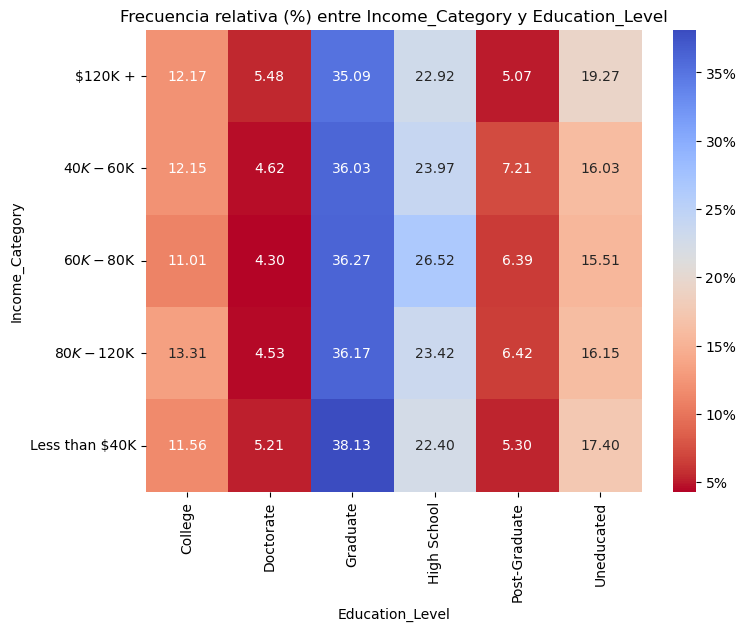

In [62]:
# Análisis bivariado entre 'Income_Category' y 'Education_Level'
bivariate_analysis(train_X, 'Income_Category', 'Education_Level')

Se observa que la distribución de ingresos es muy similar entre los distintos niveles educativos, sin diferencias claras que permitan asociar un nivel de ingresos concreto a una categoría educativa específica. Por tanto, no existe una lógica de negocio suficientemente fuerte como para imputar los valores faltantes de `Income_Category` basándonos en `Education_Level`.

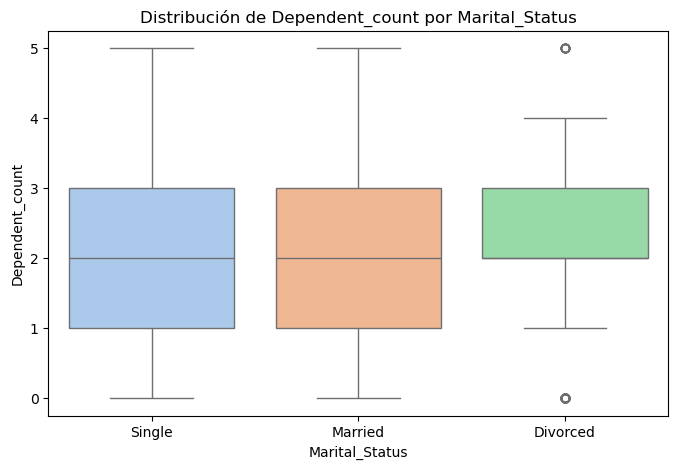

In [63]:
# Análisis bivariado entre 'Marital_Status' y 'Dependent_count'
bivariate_analysis(train_X, 'Marital_Status', 'Dependent_count')

De forma similar, el análisis entre `Marital_Status` y `Dependent_count` muestra que el número de dependientes no varía significativamente entre los distintos estados civiles.

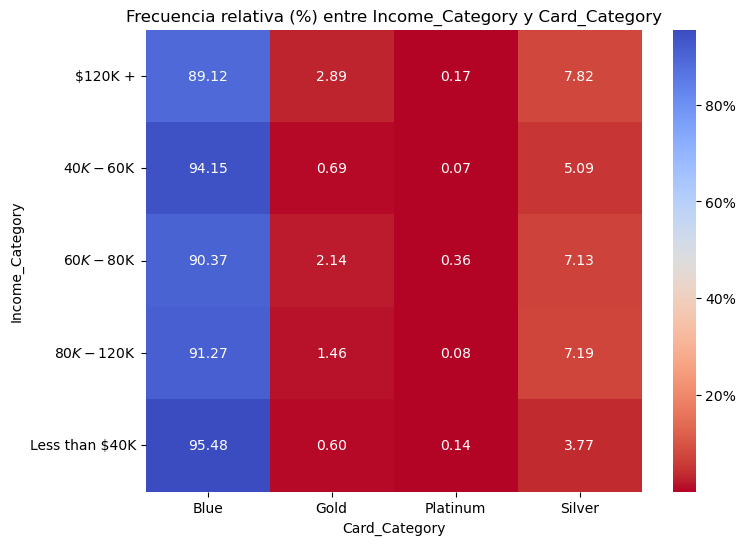

In [64]:
# Análisis bivariado entre 'Card_Category' y 'Income_Category'
bivariate_analysis(train_X, 'Income_Category', 'Card_Category')

Del mismo modo, se observa que la distribución de los tipos de tarjeta (`Card_Category`) es muy similar para todos los rangos de ingresos (`Income_Category`), sin diferencias claras que permitan asociar ingresos más altos con tarjetas de mayor categoría.



#### **Imputar con valor estimado**

Ahora, puesto que no existe una relación lógica evidente, optaremos por la imputación estadística. Para ello, nos centraremos en las variables categóricas que presentan valores faltantes y, para cada una de ellas, calcularemos su categoría más frecuente (moda). Cada valor faltante se reemplazará por esta moda correspondiente a su propia variable. De esta forma, mantendremos la distribución original de cada variable y no alteraremos información importante del dataset.

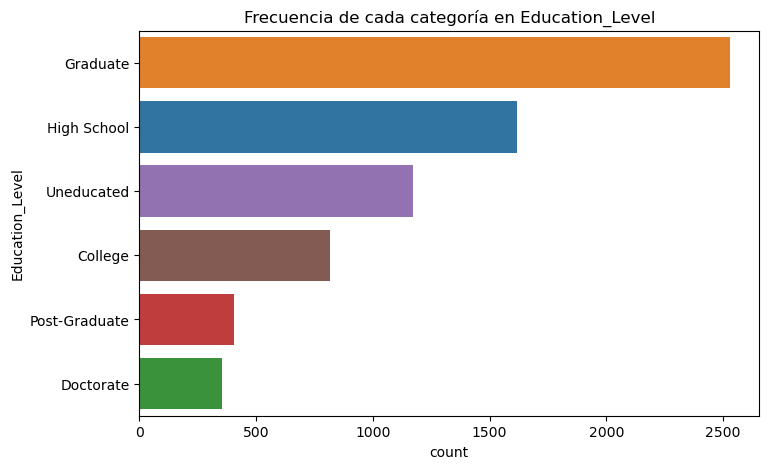

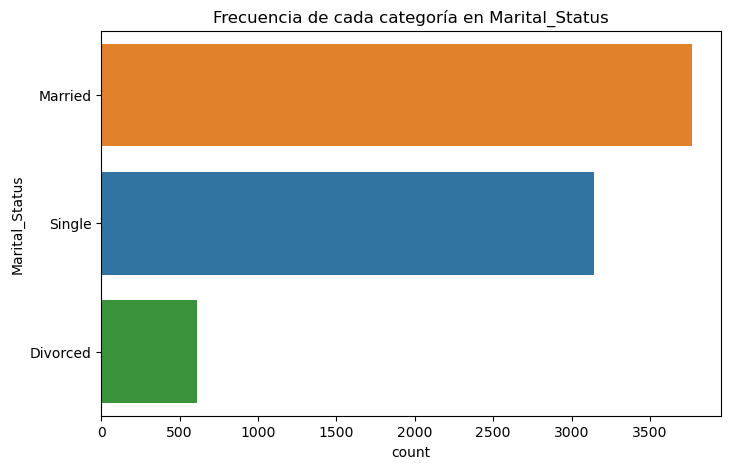

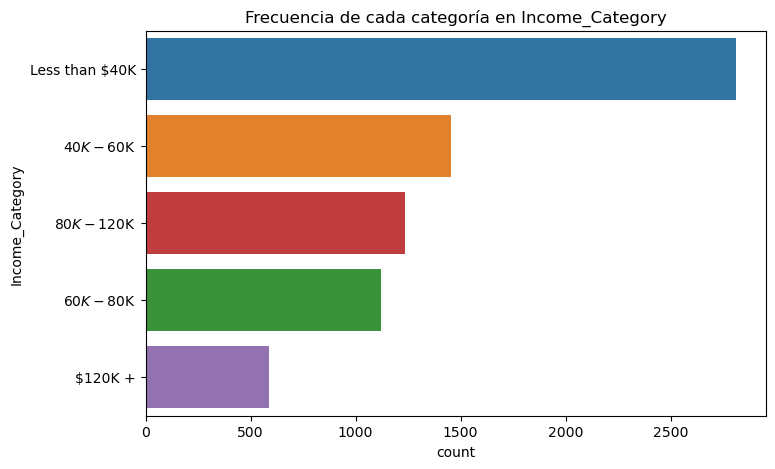

In [65]:
# Análisis univariante de las columnas con valores faltantes
for col in columns_missing:
  univariate_analysis(train_X, col)

In [66]:
# Función para calcular la moda de una columna
def calcular_moda_columna(col):
  return col.mode().values[0]

In [67]:
# Cálculo de la moda para cada columna con valores faltantes
moda_education_level = calcular_moda_columna(train_X['Education_Level'])
moda_marital_status = calcular_moda_columna(train_X['Marital_Status'])
moda_income_category = calcular_moda_columna(train_X['Income_Category'])

In [68]:
# Moda de la columna 'Education_Level'
moda_education_level

'Graduate'

In [69]:
# Moda de la columna 'Marital_Status'
moda_marital_status

'Married'

In [70]:
# Moda de la columna 'Income_Category'
moda_income_category

'Less than $40K'

In [71]:
# Imputación de valores faltantes con la moda correspondiente
train_X['Education_Level'] = train_X['Education_Level'].fillna(moda_education_level)
train_X['Marital_Status'] = train_X['Marital_Status'].fillna(moda_marital_status)
train_X['Income_Category'] = train_X['Income_Category'].fillna(moda_income_category)

In [72]:
# Verificamos que ya no hay valores nulos
train_X.isna().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [73]:
# Revisamos de nuevo los valores únicos de cada variable categórica
for col in categorical_vars:
    print(f"Valores únicos en la columna '{col}':")
    print(train_X[col].unique())
    print()

Valores únicos en la columna 'Attrition_Flag':
['Existing Customer' 'Attrited Customer']

Valores únicos en la columna 'Gender':
['F' 'M']

Valores únicos en la columna 'Education_Level':
['Graduate' 'High School' 'Doctorate' 'Post-Graduate' 'Uneducated'
 'College']

Valores únicos en la columna 'Marital_Status':
['Single' 'Married' 'Divorced']

Valores únicos en la columna 'Income_Category':
['Less than $40K' '$40K - $60K' '$60K - $80K' '$80K - $120K' '$120K +']

Valores únicos en la columna 'Card_Category':
['Blue' 'Gold' 'Silver' 'Platinum']



### **3.3. One-hot encoding**

Una vez que todas las variables categóricas tienen sentido para nuestro análisis, es necesario transformarlas a un formato numérico para poder construir nuestros modelos. Para ello, aplicaremos la técnica One-Hot Encoding, convertiendo así cada categoría en una variable binaria.

In [74]:
# Codificamos las variables 'Attrition_Flag' y 'Gender' para tener una idea previa de esto
train_X['Attrition_Flag'] = train_X['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)
train_X['Gender'] = train_X['Gender'].apply(lambda x: 1 if x == 'M' else 0)

In [75]:
train_X.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
9066,0,54,0,1,Graduate,Single,Less than $40K,Blue,36,1,3,3,3723.0,1728,0.595,99,0.678,0.464
5814,1,58,0,4,High School,Married,Less than $40K,Blue,48,1,4,3,5396.0,1803,0.493,39,0.393,0.334
792,0,45,0,4,Graduate,Single,Less than $40K,Gold,36,6,1,3,15987.0,1648,0.732,36,1.250,0.103
1791,0,34,0,2,Graduate,Single,Less than $40K,Blue,36,4,3,4,3625.0,2517,1.158,46,1.300,0.694
5011,0,49,0,2,High School,Married,$40K - $60K,Blue,39,5,3,4,2720.0,1926,0.602,61,0.794,0.708


In [76]:
# Creamos una función que nos codifique todas las variables categóricas en 1 o 0
def one_hot_encoding(df, columnas, drop_first=False):
  columnas_inexistentes = [col for col in columnas if col not in df.columns]
  if columnas_inexistentes:
      raise ValueError(f"Las columnas {columnas_inexistentes} no existen en el DataFrame.")

  # Aplicamos One-Hot Encoding utilizando get_dummies
  df_codificado = pd.get_dummies(df, columns=columnas, prefix=columnas, drop_first=drop_first)

  # Aseguramos que las nuevas columnas sean de tipo entero
  nuevas_columnas = [col for col in df_codificado.columns if any(col.startswith(f"{columna}_") for columna in columnas)]
  df_codificado[nuevas_columnas] = df_codificado[nuevas_columnas].astype(int)

  return df_codificado


In [77]:
# Seleccionamos las variables categóricas que queremos codificar
columns_to_onehot = train_X.select_dtypes(include=['object','category']).columns.tolist()
columns_to_onehot

['Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

In [78]:
# DataFrame codificado
df_onehot_train = one_hot_encoding(train_X, columns_to_onehot)
df_onehot_train

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,...,Marital_Status_Single,Income_Category_$120K +,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
9066,0,54,0,1,36,1,3,3,3723.0,1728,...,1,0,0,0,0,1,1,0,0,0
5814,1,58,0,4,48,1,4,3,5396.0,1803,...,0,0,0,0,0,1,1,0,0,0
792,0,45,0,4,36,6,1,3,15987.0,1648,...,1,0,0,0,0,1,0,1,0,0
1791,0,34,0,2,36,4,3,4,3625.0,2517,...,1,0,0,0,0,1,1,0,0,0
5011,0,49,0,2,39,5,3,4,2720.0,1926,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,1,44,0,1,38,3,2,5,4142.0,2517,...,1,0,1,0,0,0,1,0,0,0
5191,1,53,0,3,36,4,3,6,7939.0,0,...,0,0,0,0,0,1,1,0,0,0
5390,0,42,0,4,32,3,1,2,2314.0,1547,...,0,0,0,0,0,1,1,0,0,0
860,0,40,1,3,28,4,1,1,3563.0,1707,...,1,0,1,0,0,0,1,0,0,0


# 4️⃣ **Balanceo de clases**

En esta fase, el objetivo es asegurar que las clases (los clientes que se quedan frente a los que se van) estén balanceadas para evitar sesgos en el modelo. Si tenemos muchísimos datos de gente que se queda y pocos de los que se van, el modelo no aprenderá a detectar bien los abandonos. Para arreglarlo, usaremos la técnica avanzada SMOTE:

- **Sobremuestreo:** Aumentaremos artificialmente el número de ejemplos de la clase minoritaria (`Attrited_Customer`).

- **Submuestreo:** Reduciremos el número de ejemplos de la clase mayoritaria (`Existing Customer`).

In [79]:
# Calculamos la proporción que hay de cada clase
df_onehot_train.Attrition_Flag.value_counts(normalize=True)

Attrition_Flag
0    0.839526
1    0.160474
Name: proportion, dtype: float64

Dado que la variable objetivo presenta un claro desbalance (aproximadamente el 83% de los clientes permanecen activos, mientras que solo el 16% abandonan el banco), aplicaremos la técnica SMOTE para equilibrar las clases en el conjunto de entrenamiento.

In [80]:
%pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy=0.5, random_state=42)

Note: you may need to restart the kernel to use updated packages.


In [81]:
# Variables predictoras en el train
X = df_onehot_train.drop('Attrition_Flag', axis = 1)

# Variable target en el train
y = df_onehot_train['Attrition_Flag']

In [82]:
# Comprobamos el tamaño original del conjunto de datos
len(X)

8101

In [83]:
# Aplicamos SMOTE para generar nuevas observaciones de la clase minoritaria
X_res, y_res = sm.fit_resample(X,y)

In [84]:
# Comprobamos el tamaño del nuevo conjunto balanceado 
len(X_res)

10201

In [85]:
# Verificamos la nueva proporción de clases
y_res.value_counts(normalize=True)

Attrition_Flag
0    0.666699
1    0.333301
Name: proportion, dtype: float64

In [86]:
# Creamos los conjuntos de entrenamiento finales a partir del dataset balanceado
X_train = X_res.copy()
y_train = y_res.copy()

Para evaluar correctamente nuestro modelo de churn, necesitaremos también preparar nuestro conjunto de test:

In [87]:
# Creamos una copia de test_X para hacer la inferencia más adelante
X_test_original = test_X.copy()

In [88]:
# Eliminamos las columnas que no nos sirven
test_X.drop(columns=['CLIENTNUM', 'Avg_Open_To_Buy', 'Total_Trans_Amt'], inplace=True)

# Marcamos los 'Unknown' como nulos para poder limpiarlos
columns_missing = ['Education_Level', 'Marital_Status', 'Income_Category']
test_X[columns_missing] = test_X[columns_missing].replace('Unknown', np.nan)

In [89]:
# Rellenamos esos huecos con la moda (lo más frecuente) de cada columna
test_X['Education_Level'] = test_X['Education_Level'].fillna(moda_education_level)
test_X['Marital_Status'] = test_X['Marital_Status'].fillna(moda_marital_status)
test_X['Income_Category'] = test_X['Income_Category'].fillna(moda_income_category)

In [90]:
# Comprobamos que ya no quedan nulos
test_X.isna().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [91]:
# Convertimos las variables objetivo y género a binario (0 y 1)
test_X['Attrition_Flag'] = test_X['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)
test_X['Gender'] = test_X['Gender'].apply(lambda x: 1 if x == 'F' else 0)

In [92]:
# Identificamos automáticamente las columnas categóricas para el encoding
columns_to_onehot = test_X.select_dtypes(include=['object', 'category']).columns.tolist()
columns_to_onehot

['Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

In [93]:
# Aplicamos One-Hot Encoding múltiple
df_onehot_test = one_hot_encoding(test_X, columns_to_onehot)

In [94]:
# Verificamos cómo ha quedado el balanceo en el test
df_onehot_test.Attrition_Flag.value_counts(normalize=True)

Attrition_Flag
0    0.838598
1    0.161402
Name: proportion, dtype: float64

Aquí, aunque vemos que también está bastante desbalanceado, no aplicaremos SMOTE, ya que son los datos reales que queremos evaluar en el modelo para ver el comportamiento de los clientes.

In [95]:
# Variables predictoras en el test
X_test = df_onehot_test.drop('Attrition_Flag', axis = 1)

# Variable target en el test
y_test = df_onehot_test['Attrition_Flag']

In [96]:
# Mostramos las dimensiones de los conjuntos de entrenamiento y test finales
print(f"Conjunto de entrenamiento: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Conjunto de test: X_test = {X_test.shape}, y_test = {y_test.shape}")


Conjunto de entrenamiento: X_train = (10201, 31), y_train = (10201,)
Conjunto de test: X_test = (2026, 31), y_test = (2026,)


# 5️⃣ **Entrenamiento y evaluación de modelos**

A continuación, implementaremos y entrenaremos diferentes algoritmos de clasificación para predecir la probabilidad de que un cliente abandone el banco. Usaremos los siguientes modelos:
- Logistic Regression

- XGBoost

In [97]:
# Para el preprocesamiento y el modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
%pip install xgboost

# Para la visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Para las métricas
from sklearn.metrics import classification_report, confusion_matrix

Note: you may need to restart the kernel to use updated packages.


In [98]:
# Identificamos las columnas binarias: solo contienen 0 y 1
binary_cols = [col for col in X_train.columns if set(X_train[col].unique()) <= {0, 1}]

# Identificamos columnas continuas: resto de variables numéricas
continuous_cols = [col for col in X_train.columns if col not in binary_cols]

print("\nColumnas binarias:", binary_cols)
print("Columnas continuas:", continuous_cols)


Columnas binarias: ['Gender', 'Education_Level_College', 'Education_Level_Doctorate', 'Education_Level_Graduate', 'Education_Level_High School', 'Education_Level_Post-Graduate', 'Education_Level_Uneducated', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Income_Category_$120K +', 'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K', 'Income_Category_$80K - $120K', 'Income_Category_Less than $40K', 'Card_Category_Blue', 'Card_Category_Gold', 'Card_Category_Platinum', 'Card_Category_Silver']
Columnas continuas: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


### **5.1. Regresión logística**

Antes de entrenar nuestro modelo de regresión logística, es importante preparar adecuadamente los datos. Si observamos nuestro dataset, las variables continuas tienen rangos muy diferentes, por lo que será necesario hacer un escalamiento en estas variables, de forma que todas estén en un rango comparable y que nuestro modelo no quede sesgado.

Para organizar todo este flujo de preprocesamiento y entrenamiento de manera segura y reproducible, utilizaremos un pipeline. Esto garantizará que las transformaciones que apliquemos a los datos de entrenamiento se apliquen exactamente igual a los datos de prueba y a cualquier nuevo dato que queramos predecir.

In [99]:
# Configuramos el preprocesador para escalar solo las columnas continuas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols)
    ],
    remainder='passthrough'
)

# Creamos el pipeline para la Regresión Logística
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

In [100]:
# Entrenamos el modelo
logreg_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [101]:
# Comparamos el score del conjunto de train y test para ver si hay riesgo de overfitting o no
print("Training set score: {:.2f}".format(logreg_pipeline.score(X_train, y_train)))
print("Test set score: {:.2f}".format(logreg_pipeline.score(X_test, y_test)))


Training set score: 0.91
Test set score: 0.86


La diferencia entre train y test es relativamente pequeña (0.05), lo que indica que no hay un sobreajuste significativo. Esto sugiere que el modelo generaliza bien y puede considerarse razonablemente sólido para nuestras predicciones. Sin embargo, como veremos en el reporte de clasificación, el modelo todavía presenta dificultades para identificar correctamente a los clientes que abandonan, por lo que podría mejorarse con un algoritmo más potente.

In [102]:
# Predicciones en el conjunto de prueba
y_pred_logreg = logreg_pipeline.predict(X_test)
y_pred_logreg

array([0, 0, 0, ..., 0, 1, 0], shape=(2026,))

Ahora, mediremos el rendimiento del modelo utilizando métricas de clasificación:

In [103]:
# Evaluación del modelo
print("\n--- Reporte de Clasificación: Regresión Logística ---")
print(classification_report(y_test, y_pred_logreg))


--- Reporte de Clasificación: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1699
           1       0.57      0.64      0.61       327

    accuracy                           0.86      2026
   macro avg       0.75      0.77      0.76      2026
weighted avg       0.87      0.86      0.87      2026



En cuanto al **acuraccy**, el modelo acierta en el 86% de todos los casos. Sin embargo, al analizar la **precisión** por clase, vemos diferencias importantes: para la clase 1 (clientes que se van), la precisión es de 0.57, lo que significa que el modelo se equivoca con casi la mitad de las predicciones de churn. En cambio, para la clase 0 (clientes que se quedan), la precisión es alta (0.93), mostrando que el modelo identifica correctamente a los clientes que permanecen.

Esto nos indica que, aunque el modelo funciona bien para detectar clientes que no se van, tiene limitaciones para predecir correctamente el churn, por lo que no es óptimo para nuestras necesidades de retención. Para mejorar la predicción de clientes en riesgo, exploraremos un modelo más avanzado: **XGBoost**.

### **5.2. XGBoost**

Para mejorar la predicción del churn, utilizaremos XGBoost, un modelo de ensemble basado en árboles de decisión que suele manejar mejor datasets desbalanceados y capturar relaciones no lineales entre las variables.

Antes de entrenar el modelo, calcularemos el parámetro **scale_pos_weight**, que ajusta la importancia de la clase minoritaria (clientes que abandonan) para que el modelo no se sesgue hacia la clase mayoritaria:

In [104]:
from collections import Counter

# Contamos las instancias de cada clase en y_train
counter = Counter(y_train)
negativos, positivos = counter[0], counter[1]

# Calculamos scale_pos_weight
scale_pos_weight = negativos / positivos
print(f"\nScale_pos_weight para XGBoost: {scale_pos_weight:.2f}")


Scale_pos_weight para XGBoost: 2.00


In [105]:
# Creamos el modelo XGBoost para clasificación binaria
xgb_model = XGBClassifier(objective = 'binary:logistic',
                          scale_pos_weight=scale_pos_weight,
                          use_label_encoder=False,
                          eval_metrics= 'logloss',
                          random_state=42)

In [106]:
# Entrenamos el modelo con los datos de entrenamiento balanceados
xgb_model.fit(X_train, y_train)

c:\Users\Borja\miniconda3\envs\Forecasting\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:50:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [107]:
# Comparamos el score del conjunto de train y test para ver si hay riesgo de overfitting o no
print("Training set score: {:.2f}".format(xgb_model.score(X_train, y_train)))
print("Test set score: {:.2f}".format(xgb_model.score(X_test, y_test)))

Training set score: 1.00
Test set score: 0.92


En este caso, la diferencia entre el score del conjunto de entrenamiento y del conjunto de prueba indica que el modelo está aprendiendo mucho los datos de entrenamiento, lo que puede considerarse un leve signo de overfitting. Sin embargo, el 92 % de acierto en el conjunto de prueba sigue siendo muy bueno y muestra que el modelo generaliza de forma adecuada. Esto sugiere que, aunque el modelo es muy potente y ligeramente sobreajustado, ofrece una mejor capacidad para identificar clientes que abandonan en comparación con la regresión logística.

In [108]:
# Realizamos predicciones sobre el conjunto de prueba
y_pred_xgb =xgb_model.predict(X_test)
y_pred_xgb

array([0, 0, 0, ..., 0, 0, 0], shape=(2026,))

In [109]:
# Evaluación del modelo
print("\n--- Reporte de Clasificación: XGBoost ---")
print(classification_report(y_test, y_pred_xgb))


--- Reporte de Clasificación: XGBoost ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1699
           1       0.77      0.74      0.75       327

    accuracy                           0.92      2026
   macro avg       0.86      0.85      0.85      2026
weighted avg       0.92      0.92      0.92      2026



Se observa que el modelo presenta un rendimiento muy elevado en la clase 0 (clientes que permanecen), identificándolos con gran precisión. En cambio, para la clase 1 (clientes que abandonan), aunque existe una mejora notable respecto a la regresión logística, el modelo todavía presenta algunas dificultades y no consigue predecir estos casos con total seguridad.

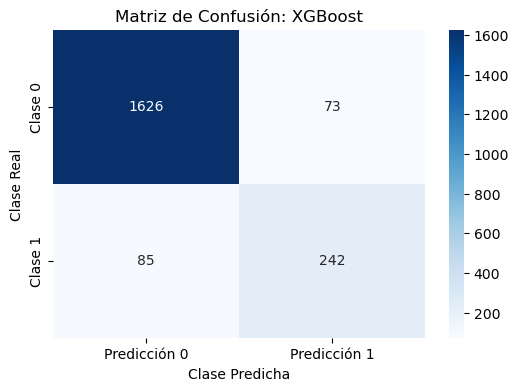

In [110]:
# Generamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred_xgb)

# Convertimos a DataFrame para visualización más clara
cm_df = pd.DataFrame(cm, index=['Clase 0', 'Clase 1'], columns=['Predicción 0', 'Predicción 1'])

# Visualizamos la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: XGBoost')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()

- **Clientes que permanecen (Clase 0)**

El modelo clasifica correctamente a 1626 clientes que realmente se quedaron.
Solo 73 clientes que se quedaron fueron clasificados erróneamente como churn.

- **Clientes que abandonan (Clase 1)**

El modelo identifica correctamente a 242 clientes que realmente abandonaron.
Sin embargo, 85 clientes que abandonaron no fueron detectados (falsos negativos).

#### **Elección del mejor modelo**
Dado que el objetivo de nuestro proyecto es detectar clientes en riesgo de abandono para implementar estrategias de retención, XGBoost se posiciona como el modelo más adecuado, ya que ofrece un mejor equilibrio entre rendimiento general y capacidad de identificar churn.

In [111]:
import joblib

# Guardamos el modelo XGBoost entrenado
joblib.dump(xgb_model, "../models/modelo_churn.joblib")

['../models/modelo_churn.joblib']

# 6️⃣ **Interpretación de variables en el modelo**

Para comprender por qué el modelo predice que un cliente se va o se queda, es importante analizar qué variables son más influyentes y cómo afectan la probabilidad de churn. Para ello, lo haremos desde dos perspectivas complementarias:

**1. Importancia de las variables**<br>
Utilizando la funcionalidad de XGBoost, identificaremos cuáles son las variables que más han afectado en la predicción de determinar si un cliente va a abandonar o permanecer.

**2. Efecto estadístico de las variables**<br>
A través de visualizaciones estadísticas (como boxplots), veremos el efecto positivo y negativo de esas variables más influyentes contra el target.

In [112]:
# Obtenemos la importancia de las características
importancias = xgb_model.get_booster().get_score(importance_type='gain')

# Convertimos a DataFrame para manejarlo mejor
importancias_df = pd.DataFrame({
    'Feature': list(importancias.keys()),
    'Importance': list(importancias.values())
})

# Ordenamos por importancia descendentemente
importancias_df = importancias_df.sort_values(by='Importance', ascending=False)

C:\Users\Borja\AppData\Local\Temp\ipykernel_6784\3809370142.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importancias_df.head(20), palette='viridis')


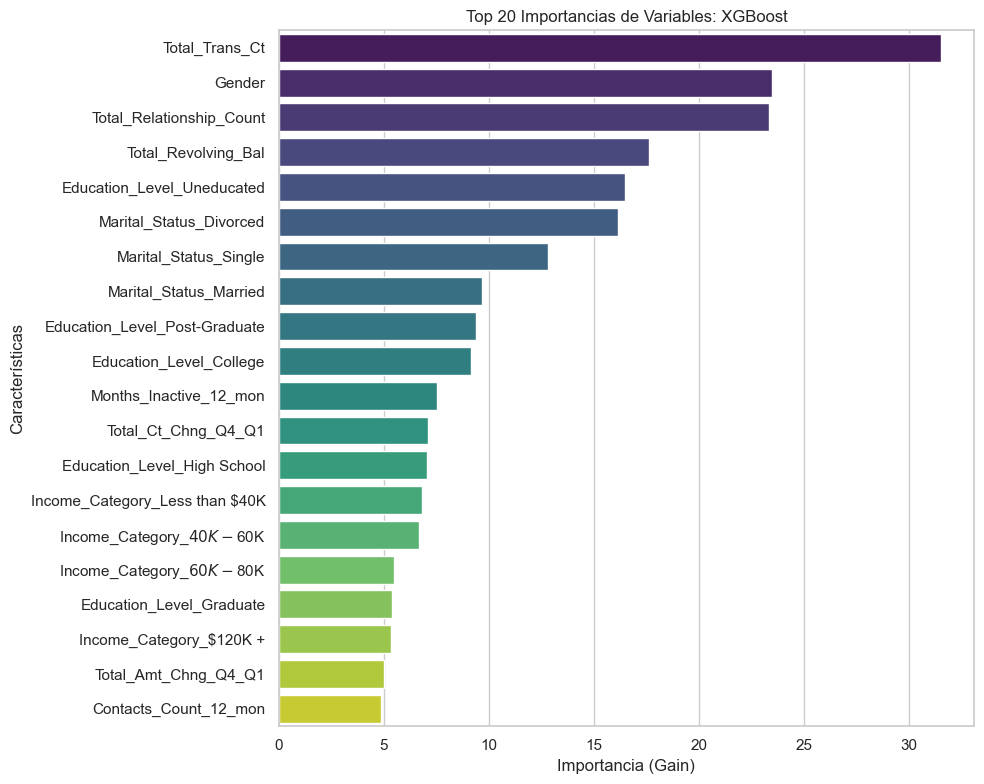

In [113]:
# Configuramos el estilo de los gráficos
sns.set(style="whitegrid")

# Creamos un gráfico de barras para la importancia de las variables
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importancias_df.head(20), palette='viridis')
plt.title('Top 20 Importancias de Variables: XGBoost')
plt.xlabel('Importancia (Gain)')
plt.ylabel('Características')
plt.tight_layout()
plt.show()

In [114]:
# Top 30 variables según importancia
top_variables = importancias_df.head(30)['Feature'].tolist()

# Seleccionamos las variables que sospechamos que influyen en la fuga
# Filtramos solo las que se pueden accionar
accionables = [var for var in top_variables if var in [
    'Months_Inactive_12_mon',
    'Contacts_Count_12_mon',
    'Total_Relationship_Count',
    'Credit_Limit',
    'Total_Revolving_Bal',
    'Total_Trans_Ct',
    'Avg_Utilization_Ratio'
]]

print(f"Las variables accionables con riesgo de fuga son: {accionables}")

# Variable target
output_variable = 'Attrition_Flag'

Las variables accionables con riesgo de fuga son: ['Total_Trans_Ct', 'Total_Relationship_Count', 'Total_Revolving_Bal', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Avg_Utilization_Ratio']


In [115]:
# Filtramos el dataset de test con estas variables clave
clientes_out_final = X_test[accionables].copy()  
clientes_out_final[output_variable] = y_test.values
clientes_out_final

,Total_Trans_Ct,Total_Relationship_Count,Total_Revolving_Bal,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Avg_Utilization_Ratio,Attrition_Flag
3781,64,4,1508,3,4,2991.0,0.504,0
2922,79,5,1569,5,4,2192.0,0.716,0
5070,67,4,987,3,3,1734.0,0.569,0
7246,74,4,1516,2,3,4786.0,0.317,0
623,35,3,2170,3,2,3714.0,0.584,0
...,...,...,...,...,...,...,...,...
1937,69,3,1678,1,3,13395.0,0.125,0
4705,42,2,1791,2,4,2231.0,0.803,1
8548,75,1,1235,2,3,5594.0,0.221,0
1346,36,6,1354,2,2,8713.0,0.155,0


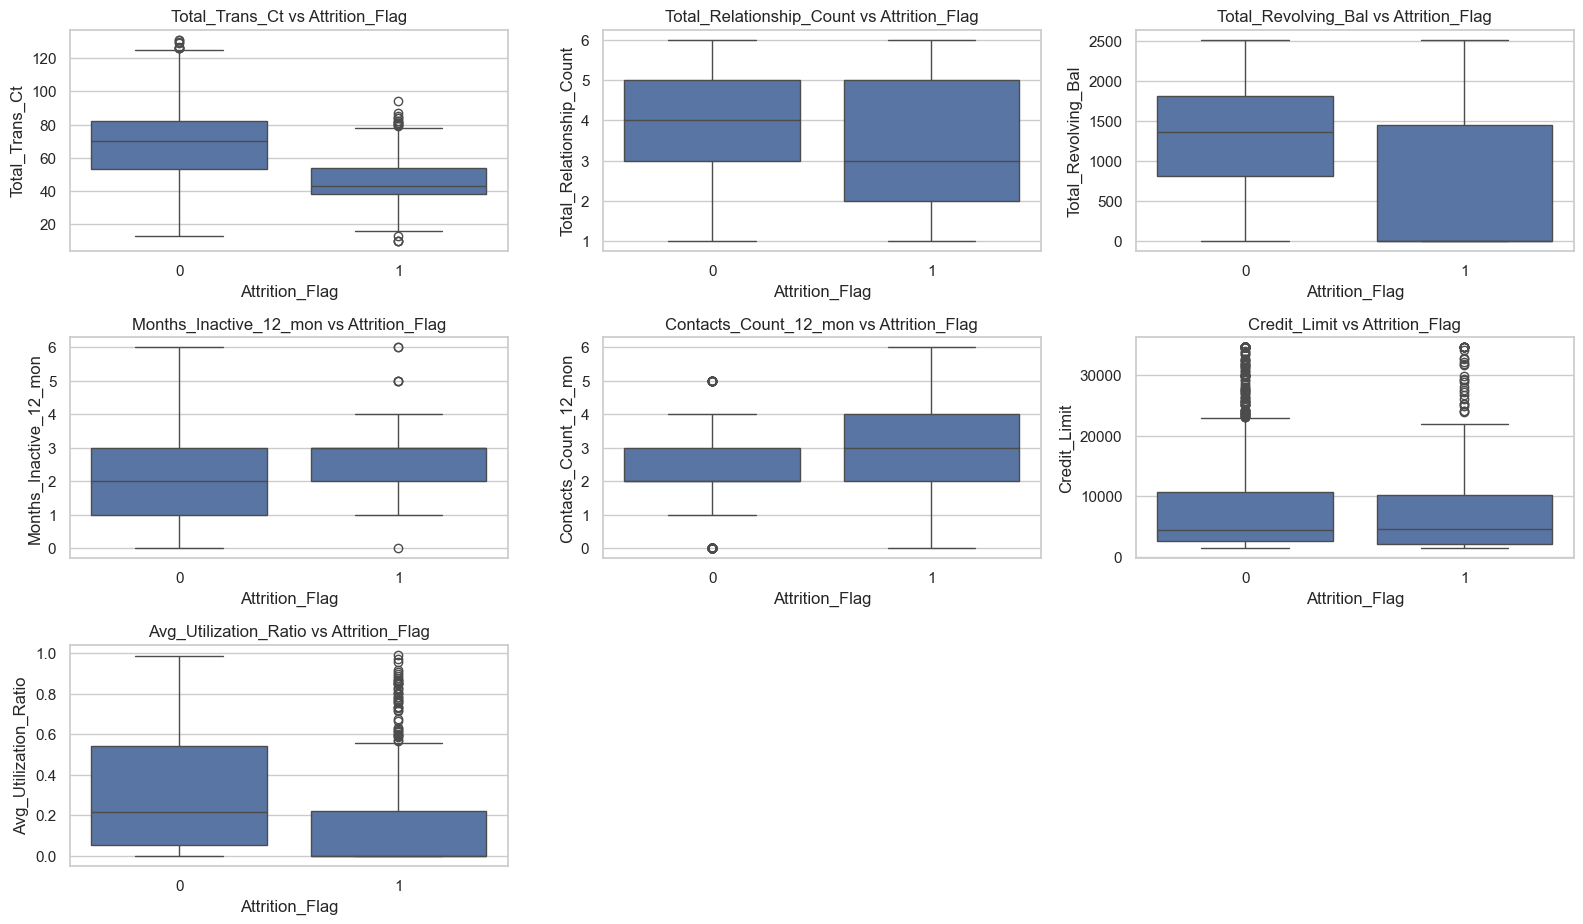

In [116]:
# Graficamos un boxplot de cada variable clave frente al target para ver su importancia y 
# tomar decisiones que hagan que los clientes permanezcan en el banco
plt.figure(figsize=(16, 12))
for i, variable in enumerate(accionables, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=clientes_out_final, x='Attrition_Flag', y=variable)
    plt.title(f'{variable} vs Attrition_Flag')

plt.tight_layout()
plt.show()

#### **Conclusiones para retener nuestros clientes**

- **Límite de crédito (`Credit_Limit`):** Los clientes con límites bajos tienen más probabilidad de abandonar. $\Rightarrow$ Ofreceremos un incremento moderado en su límite para fomentar que permanezcan.

- **Número de productos utilizados (`Total_Relationship_Count`):** Aquellos clientes con pocos productos presentan mayor riesgo de churn.<br>
$\Rightarrow$ Les ofreceremos productos adicionales adaptados a su perfil para aumentar su engagement.

- **Uso de la tarjeta y aplicación (`Avg_Utilization_Ratio`, `Total_Trans_Ct`):** La baja actividad en los últimos 12 meses se relaciona con abandono.<br>
$\Rightarrow$ Propondremos incentivos como cashback o promociones en la app para motivar un uso más frecuente.

# **7️⃣ Inferencia**

En esta sección aplicaremos el modelo final entrenado a los nuevos clientes para estimar la probabilidad de que abandonen el banco. Calcularemos tanto la predicción de la clase `Attrition_Flag` como la probabilidad de churn para cada cliente, de manera que podamos identificar a aquellos con mayor riesgo y planificar acciones de retención personalizadas.

In [117]:
# Calculamos las probabilidades de churn en el modelo
churn_proba = xgb_model.predict_proba(X_test)[:, 1]
attrition_pred = xgb_model.predict(X_test)

In [118]:
# Creamos un DataFrame final del conjunto test para la inferencia
clientes_inferencia = X_test_original

# Añadimos una columna con las probabilidades de churn para cada cliente
clientes_inferencia['churn_proba'] = churn_proba

# Cambiamos la predicción final de clase para cada cliente
clientes_inferencia['Attrition_Flag'] = attrition_pred

# Reordenamos las columnas para que 'churn_proba' y 'Attrition_Flag' estén al final
cols_originales = [c for c in clientes_inferencia.columns if c not in ["churn_proba", "Attrition_Flag"]]
clientes_inferencia = clientes_inferencia[cols_originales + ["churn_proba", "Attrition_Flag"]]

# Mostramos los primeros resultados 
clientes_inferencia.reset_index(drop=True).head()

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,churn_proba,Attrition_Flag
0,719455083,48,F,3,Uneducated,Single,Less than $40K,Blue,39,4,...,2991.0,1508,1483.0,0.703,3734,64,0.882,0.504,0.000768,0
1,773503308,59,M,1,Uneducated,Single,Less than $40K,Blue,53,5,...,2192.0,1569,623.0,0.706,4010,79,0.717,0.716,0.000297,0
2,715452408,37,F,2,Graduate,Divorced,Less than $40K,Blue,36,4,...,1734.0,987,747.0,0.879,4727,67,0.914,0.569,0.000857,0
3,711264033,47,M,3,Doctorate,Divorced,$40K - $60K,Blue,36,4,...,4786.0,1516,3270.0,0.940,4973,74,0.850,0.317,0.164790,0
4,718943508,42,M,3,Unknown,Single,$80K - $120K,Blue,33,3,...,3714.0,2170,1544.0,0.524,1454,35,0.522,0.584,0.694938,1


In [119]:
# Exportamos el dataset de inferencia a CSV
clientes_inferencia.to_csv("../data/processed/clientes_inferencia.csv", index=False)

# 8️⃣ **Generar comunicaciones con GPT**

El objetivo final será crear estrategias y comunicaciones para retener a los clientes que hemos identificado con riesgo de fuga. Para ello, seguiremos los siguientes pasos:

- **Filtrar clientes en riesgo:** Localizaremos a los usuarios que el modelo dice que tienen una probabilidad alta de abandonar.

- **Generar estrategias personalizadas:** Diseñaremos incentivos específicos (como descuentos o mejoras de tarjeta) según el perfil de cada cliente.

- **Crear comunicaciones personalizadas:** Usaremos ChatGPT para redactar correos electrónicos potentes que ofrezcan esos beneficios relevantes de forma cercana.

In [120]:
# Filtramos solo los clientes que el modelo ha predicho que van a abandonar el banco
clientes_out = clientes_inferencia[clientes_inferencia['Attrition_Flag'] == 1].reset_index(drop=True)
clientes_out.head()

,CLIENTNUM,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,churn_proba,Attrition_Flag
0,718943508,42,M,3,Unknown,Single,$80K - $120K,Blue,33,3,...,3714.0,2170,1544.0,0.524,1454,35,0.522,0.584,0.694938,1
1,712050933,48,M,4,College,Married,$80K - $120K,Blue,32,5,...,25190.0,0,25190.0,0.467,1533,41,0.323,0.000,0.942788,1
2,713696808,46,F,3,High School,Married,Less than $40K,Blue,39,3,...,1801.0,316,1485.0,0.494,2252,42,0.400,0.175,0.530967,1
3,779749908,48,M,4,College,Married,$60K - $80K,Gold,33,2,...,34516.0,2061,32455.0,0.722,1350,32,0.455,0.060,0.941823,1
4,708708858,50,F,1,Graduate,Single,Less than $40K,Blue,36,1,...,2422.0,502,1920.0,0.997,2548,46,0.484,0.207,0.999916,1


In [121]:
# Instalamos la librería de OpenAI para la generación de textos con GPT-4
%pip install openai
from openai import OpenAI

USE_API = False  # Cambia a True si tienes créditos de OpenAI

# Solo si USE_API es True
if USE_API:
    client = OpenAI()

Note: you may need to restart the kernel to use updated packages.


In [122]:
# Creamos una función que genere un prompt personalizado para cada cliente en riesgo de fuga,
# basado en sus características y con un tono adaptado a su perfil

def generar_prompt(cliente):
    # Ajustamos el tono según la edad
    if cliente['Customer_Age'] < 30:
        tono = "relajado, amigable y con un toque de cercanía. Usa expresiones más coloquiales."
    elif 30 <= cliente['Customer_Age'] <= 50:
        tono = "profesional pero accesible. Mantén un equilibrio entre seriedad y amabilidad."
    else:
        tono = "formal y respetuoso, con un enfoque en mostrar confianza y seguridad."

    prompt = f"""
    Este cliente tiene {cliente['Customer_Age']} años, un límite de crédito de {cliente['Credit_Limit']}, ha estado inactivo {cliente['Months_Inactive_12_mon']} meses en los últimos 12 meses,
    ha realizado {cliente['Total_Trans_Ct']} transacciones y tiene un ratio de utilización de {cliente['Avg_Utilization_Ratio']}. Además, su Total_Relationship_Count es {cliente['Total_Relationship_Count']}.

    Si el límite de crédito es bajo, ofrécele un aumento de un 5% de crédito para retenerlo.
    Si ha estado inactivo muchos meses o tiene pocas transacciones, ofrécele un incentivo como cashback del 0.1% al 0.3% para volver a utilizar los productos.
    Si tiene baja utilización ofrécele intereses menores reduciendo 1% o 2% el interés del crédito.
    Si tiene un solo producto (Total_Relationship_Count bajo), ofrécele otro producto del banco con descuento.

    Ofrece únicamente un beneficio basado en la variable con el rendimiento más bajo.

    Genera un email de comunicación personalizado utilizando un tono {tono}. El mensaje debe ser claro y adaptarse al perfil del cliente según sus datos.
    """
    return prompt

In [ ]:
# Creamos una función que envíe un prompt a GPT-4 para generar un email personalizado para cada
# cliente en riesgo de fuga, con una oferta concreta basada en su variable más débil

def enviar_a_gpt(cliente):
    # =========================
    # MODO API (si hay crédito)
    # =========================
    if USE_API:
        prompt = generar_prompt(cliente)
        completion = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "system",
                    "content": "Eres un asistente que redacta correos personalizados para retener clientes de Banco Hispanis."
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ]
        )
        return completion.choices[0].message.content

    # =========================
    # MODO GRATUITO (simulación)
    # =========================

    import random

    # Lista de gestores
    gestores = [
        {"nombre": "Ana", "apellido": "Torres", "email": "ana.torres@bancohispanis.com"},
        {"nombre": "Carlos", "apellido": "Gómez", "email": "carlos.gomez@bancohispanis.com"},
        {"nombre": "Lucía", "apellido": "Martínez", "email": "lucia.martinez@bancohispanis.com"},
        {"nombre": "Javier", "apellido": "López", "email": "javier.lopez@bancohispanis.com"},
        {"nombre": "Laura", "apellido": "Sánchez", "email": "laura.sanchez@bancohispanis.com"},
        {"nombre": "Daniel", "apellido": "Pérez", "email": "daniel.perez@bancohispanis.com"},
        {"nombre": "María", "apellido": "Romero", "email": "maria.romero@bancohispanis.com"}
    ]

    # Elegir gestor aleatoriamente
    gestor = random.choice(gestores)
    gestor_nombre = f"{gestor['nombre']} {gestor['apellido']}"
    gestor_email = gestor["email"]

    # Saludo según edad
    if cliente["Customer_Age"] < 30:
        saludo = "Hola"
    elif cliente["Customer_Age"] <= 50:
        saludo = "Estimad@"
    else:
        saludo = "Distinguid@"

    # -------------------------
    # Detectar variable más débil
    # -------------------------
    if cliente["Credit_Limit"] < 5000:
        motivo = (
            f"Hemos visto que tu límite de crédito actual es de {cliente['Credit_Limit']} €, "
            "y creemos que disponer de un mayor margen puede darte más comodidad en tu día a día."
        )
        beneficio = "un aumento del 5 % en tu límite de crédito"

    elif cliente["Months_Inactive_12_mon"] > 6:
        motivo = (
            f"En los últimos 12 meses has estado {int(cliente['Months_Inactive_12_mon'])} meses sin actividad, "
            "algo que puede ocurrir cuando cambian las rutinas."
        )
        beneficio = "un cashback del 0.3 % en tus próximas compras"

    elif cliente["Avg_Utilization_Ratio"] < 0.2:
        motivo = (
            f"Actualmente tu nivel de utilización del crédito es bajo "
            f"(ratio de {cliente['Avg_Utilization_Ratio']:.2f}), "
            "y queremos que puedas aprovecharlo en mejores condiciones."
        )
        beneficio = "una reducción del interés de tu crédito de entre un 1 % y un 2 %"

    elif cliente["Total_Relationship_Count"] == 1:
        motivo = (
            "Actualmente solo cuentas con un producto en Banco Hispanis, "
            "y creemos que podrías beneficiarte de una relación más completa con nosotros."
        )
        beneficio = "un nuevo producto del banco con condiciones especiales"

    else:
        motivo = (
            "Tu perfil muestra un uso equilibrado de nuestros productos, "
            "y queremos seguir ofreciéndote ventajas adaptadas a ti."
        )
        beneficio = "un beneficio exclusivo adaptado a tu perfil"

    # -------------------------
    # Email final
    # -------------------------
    return f"""
{saludo} cliente,

Espero que se encuentre bien. Mi nombre es {gestor_nombre} y soy tu gestor/a de cuentas en Banco Hispanis.

{motivo}

Por este motivo, queremos ofrecerte {beneficio}, con el objetivo de que sigas sacando el máximo partido a nuestros servicios.

Si tienes cualquier duda o necesitas asesoramiento para aprovechar mejor tu cuenta, no dudes en ponerte en contacto conmigo. Estaré encantad@ de ayudarte.

Un saludo muy cordial,

{gestor_nombre}
Gestor/a de Cuentas
Banco Hispanis
Tel: 123-456-789
Email: {gestor_email}
"""


In [124]:
# Probamos la función con el cliente que tenga el menor límite de crédito para ver el email que se le generaría
cliente = clientes_out[clientes_out.Credit_Limit == clientes_out.Credit_Limit.min()].iloc[1]

email = enviar_a_gpt(cliente)
print(email)



Estimad@ cliente,

Espero que se encuentre bien. Mi nombre es María Romero y soy tu gestora de cuentas en Banco Hispanis.

Hemos visto que tu límite de crédito actual es de 1438.3 €, y creemos que disponer de un mayor margen puede darte más comodidad en tu día a día.

Por este motivo, queremos ofrecerte un aumento del 5 % en tu límite de crédito, con el objetivo de que sigas sacando el máximo partido a nuestros servicios.

Si tienes cualquier duda o necesitas asesoramiento para aprovechar mejor tu cuenta, no dudes en ponerte en contacto conmigo. Estaré encantada de ayudarte.

Un saludo muy cordial,

María Romero
Gestora de Cuentas
Banco Hispanis
Tel: 123-456-789
Email: maria.romero@bancohispanis.com



In [125]:
# Creamos una función que recorra todos los clientes en riesgo de fuga y genere una
# comunicación personalizada para cada uno

def generar_comunicaciones(data):
    comunicaciones = []
    for _, cliente in data.iterrows():
        respuesta = enviar_a_gpt(cliente)
        comunicaciones.append(respuesta)
        print("📩 Comunicación para cliente:\n")
        print(respuesta)
        print("-" * 80)
    return comunicaciones

In [126]:
# Generamos las comunicaciones personalizadas para los 5 primeros clientes en riesgo de fuga
comunicaciones = generar_comunicaciones(clientes_out.head(5))

📩 Comunicación para cliente:


Estimad@ cliente,

Espero que se encuentre bien. Mi nombre es Ana Torres y soy tu gestora de cuentas en Banco Hispanis.

Hemos visto que tu límite de crédito actual es de 3714.0 €, y creemos que disponer de un mayor margen puede darte más comodidad en tu día a día.

Por este motivo, queremos ofrecerte un aumento del 5 % en tu límite de crédito, con el objetivo de que sigas sacando el máximo partido a nuestros servicios.

Si tienes cualquier duda o necesitas asesoramiento para aprovechar mejor tu cuenta, no dudes en ponerte en contacto conmigo. Estaré encantada de ayudarte.

Un saludo muy cordial,

Ana Torres
Gestora de Cuentas
Banco Hispanis
Tel: 123-456-789
Email: ana.torres@bancohispanis.com

--------------------------------------------------------------------------------
📩 Comunicación para cliente:


Estimad@ cliente,

Espero que se encuentre bien. Mi nombre es Daniel Pérez y soy tu gestora de cuentas en Banco Hispanis.

Actualmente tu nivel de utiliz